In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**Part 1A - Data Preparation & Asset Selection**


In [9]:
import pandas as pd # Dataframe
import numpy as np # MATHS
import matplotlib.pyplot as plt # Graphs / Visuals
from pathlib import Path # Folder Structure
excel_file_path = "/content/drive/MyDrive/Dataset_2026.xlsx" # Please update this path to your file in Google Drive
df = pd.read_excel(excel_file_path)
df['Date'] = pd.to_datetime(df['Date']) # Convert to datetime format
df.set_index('Date', inplace=True)  # Set as index
df.head()

,AAPL,MSFT,SAP.DE,ASML.AS,TM,IEF,TLT,IBGX.L,IEAC.L,2561.T,GLD,SLV,USO,UNG,JJC,EURUSD=X,GBPUSD=X,JPY=X,AUDUSD=X,CAD=X
Date,,,,,,,,,,,,,,,,,,,,
2021-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.218027,1.367301,103.225998,0.770297,1.23499
2021-01-04,129.410004,217.690002,105.320000,406.250000,153.289993,119.980003,157.539993,158.229996,136.839996,2732.0,182.330002,25.35,32.380001,37.799999,17.971270,1.225070,1.368420,103.238998,0.771230,1.27221
2021-01-05,131.009995,217.899994,105.040001,406.899994,153.399994,119.699997,156.369995,158.100006,136.770004,2735.0,182.869995,25.67,33.939999,39.119999,18.431999,1.225160,1.357160,103.125000,0.767100,1.27810
2021-01-06,126.599998,212.250000,105.480003,402.850006,153.529999,119.000000,153.160004,158.339996,136.550003,2733.0,179.899994,25.34,34.110001,39.320000,18.521900,1.230027,1.362955,102.678001,0.776600,1.26747
2021-01-07,130.919998,218.289993,104.519997,403.899994,152.669998,118.580002,151.809998,158.520004,136.539993,2726.0,179.479996,25.26,34.529999,38.799999,18.651871,1.234111,1.362528,103.024002,0.781700,1.26654


Data Cleaning and Alignment


Reasoning: The dataset includes a row for January 1, 2021, which is New Year's Day, a public holiday in all markets. Most assets show NaN on this date because no trading happened, but FX assets show a value since currency markets can quote on this day. This creates a data issue. When simple returns are calculated using pct_change(), FX returns on January 4, 2021, are based on the January 1 price instead of the last trading day, leading to an overstated first-day return. To fix this, the January 1 row is removed before calculating returns, ensuring all assets start on January 4, 2021, and that first-day returns are consistent across all asset types.

In [10]:
# Identify and handle missing values within the time series data. Ensure all time series are aligned for consistent analysis.
# Ensure the index is a datetime object
# The 'Date' column was likely already set as the index, causing a KeyError when trying to access df['Date']
# This line ensures the existing index is treated as datetime
if not pd.api.types.is_datetime64_any_dtype(df.index):
    df.index = pd.to_datetime(df.index)

# Drop irrelevant columns if they exist
# This prevents KeyError if 'Column1' or 'Column2' are not present
columns_to_drop = ['Column1', 'Column2'] # Example columns to drop
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
if existing_columns_to_drop:
    df.drop(existing_columns_to_drop, axis=1, inplace=True)

# Check for missing values before handling
missing_values_before = df.isnull().sum()
print("Missing values before handling:")
print(missing_values_before)

# Handle missing values by forward-filling, then backward-filling to catch leading NaNs
# This propagates the last valid observation forward, then the next valid observation backward
df.ffill(inplace=True)
df.bfill(inplace=True)

# Verify no more missing values
missing_values_after = df.isnull().sum()
print("\nMissing values after ffill and bfill:")
print(missing_values_after)

df.head()

Missing values before handling:
AAPL         49
MSFT         49
SAP.DE       29
ASML.AS      22
TM           49
IEF          49
TLT          49
IBGX.L       43
IEAC.L       42
2561.T       83
GLD          49
SLV          49
USO          49
UNG          49
JJC         685
EURUSD=X      3
GBPUSD=X      3
JPY=X         3
AUDUSD=X      3
CAD=X         3
dtype: int64

Missing values after ffill and bfill:
AAPL        0
MSFT        0
SAP.DE      0
ASML.AS     0
TM          0
IEF         0
TLT         0
IBGX.L      0
IEAC.L      0
2561.T      0
GLD         0
SLV         0
USO         0
UNG         0
JJC         0
EURUSD=X    0
GBPUSD=X    0
JPY=X       0
AUDUSD=X    0
CAD=X       0
dtype: int64


,AAPL,MSFT,SAP.DE,ASML.AS,TM,IEF,TLT,IBGX.L,IEAC.L,2561.T,GLD,SLV,USO,UNG,JJC,EURUSD=X,GBPUSD=X,JPY=X,AUDUSD=X,CAD=X
Date,,,,,,,,,,,,,,,,,,,,
2021-01-01,129.410004,217.690002,105.320000,406.250000,153.289993,119.980003,157.539993,158.229996,136.839996,2732.0,182.330002,25.35,32.380001,37.799999,17.971270,1.218027,1.367301,103.225998,0.770297,1.23499
2021-01-04,129.410004,217.690002,105.320000,406.250000,153.289993,119.980003,157.539993,158.229996,136.839996,2732.0,182.330002,25.35,32.380001,37.799999,17.971270,1.225070,1.368420,103.238998,0.771230,1.27221
2021-01-05,131.009995,217.899994,105.040001,406.899994,153.399994,119.699997,156.369995,158.100006,136.770004,2735.0,182.869995,25.67,33.939999,39.119999,18.431999,1.225160,1.357160,103.125000,0.767100,1.27810
2021-01-06,126.599998,212.250000,105.480003,402.850006,153.529999,119.000000,153.160004,158.339996,136.550003,2733.0,179.899994,25.34,34.110001,39.320000,18.521900,1.230027,1.362955,102.678001,0.776600,1.26747
2021-01-07,130.919998,218.289993,104.519997,403.899994,152.669998,118.580002,151.809998,158.520004,136.539993,2726.0,179.479996,25.26,34.529999,38.799999,18.651871,1.234111,1.362528,103.024002,0.781700,1.26654


Extract and Process Equity Data


Reasoning: First, I will calculate daily simple returns for all equity columns using the pct_change() method. Then, I will define the number of trading days per year as 252. Next, I will calculate the annualized mean returns and annualized volatility for each equity. After that, I will assume a risk-free rate of 0 and compute the Sharpe Ratio for each equity. Finally, I will combine all these metrics into a new DataFrame and display it.



To calculate the daily simple returns, I will first select the specified equity columns from the DataFrame `df` and then apply the `.pct_change()` method to these columns, storing the result in `daily_returns_df`.





In [11]:
equity_columns = ['AAPL', 'MSFT', 'SAP.DE', 'ASML.AS', 'TM']
daily_returns_df = df[equity_columns].pct_change()
print("Daily Simple Returns for Equity Columns (all rows):")
print(daily_returns_df)


Daily Simple Returns for Equity Columns (all rows):
                AAPL      MSFT    SAP.DE   ASML.AS        TM
Date                                                        
2021-01-01       NaN       NaN       NaN       NaN       NaN
2021-01-04  0.000000  0.000000  0.000000  0.000000  0.000000
2021-01-05  0.012364  0.000965 -0.002659  0.001600  0.000718
2021-01-06 -0.033662 -0.025929  0.004189 -0.009953  0.000847
2021-01-07  0.034123  0.028457 -0.009101  0.002606 -0.005602
...              ...       ...       ...       ...       ...
2026-01-28 -0.007086  0.002185  0.003068 -0.019054 -0.023336
2026-01-29  0.007175 -0.099931 -0.160702 -0.002009  0.037370
2026-01-30  0.004646 -0.007405  0.036083  0.019799 -0.000925
2026-02-02  0.040581 -0.016082  0.026618  0.007568  0.020806
2026-02-03 -0.001963 -0.028722 -0.046259 -0.028086 -0.000691

[1326 rows x 5 columns]



I will define the `trading_days_per_year` variable with the value 252 as instructed.



In [12]:
trading_days_per_year = 252
print(f"Number of trading days per year: {trading_days_per_year}")

Number of trading days per year: 252


## Calculate Annualized Mean Returns of Equity



**Reasoning**:
To calculate the annualized mean returns, I will first compute the mean of the daily simple returns for each equity column and then multiply by the `trading_days_per_year` constant. The result will be stored in `annualized_mean_returns`.



In [13]:
annualized_mean_returns = daily_returns_df.mean() * trading_days_per_year
print("Annualized Mean Returns:")
print(annualized_mean_returns)

Annualized Mean Returns:
AAPL       0.176520
MSFT       0.153769
SAP.DE     0.119736
ASML.AS    0.274442
TM         0.111495
dtype: float64


## Calculate Annualized Volatility



**Reasoning**:
To calculate the annualized volatility, I will first compute the standard deviation of the daily simple returns for each equity and then multiply by the square root of the `trading_days_per_year` constant. The result will be stored in `annualized_volatility`.

 The risk-free rate is set at 0% for simplicity and easy comparison across assets. Although short-term interest rates were high during parts of the sample period, applying a US-based risk-free rate to a multi-currency, multi-asset portfolio can complicate matters. For instance, the appropriate risk-free rate for IBGX.L would be the Bank of England base rate, not the Fed Funds rate. Since the portfolio includes EUR, GBP, JPY, USD, and CAD-denominated assets without a single base currency, using 0% as a neutral benchmark is the best way to screen and compare assets at this stage. All Sharpe Ratios should be viewed relative to each other rather than as absolute measures of risk-adjusted performance.




In [14]:
annualized_volatility = daily_returns_df.std() * np.sqrt(trading_days_per_year)
print("Annualized Volatility:")
print(annualized_volatility)

Annualized Volatility:
AAPL       0.272700
MSFT       0.256139
SAP.DE     0.252580
ASML.AS    0.373215
TM         0.258434
dtype: float64


## Calculate Sharpe Ratio



**Reasoning**:
To calculate the Sharpe Ratio, I will first define the risk-free rate as 0, then use the previously calculated `annualized_mean_returns` and `annualized_volatility` to compute the Sharpe Ratio. The result will be stored in `sharpe_ratio`.



In [15]:
risk_free_rate = 0.0 # Assuming a risk-free rate of 0 as per the task
sharpe_ratio = (annualized_mean_returns - risk_free_rate) / annualized_volatility
print("Sharpe Ratio (Risk-Free Rate = 0):")
print(sharpe_ratio)

Sharpe Ratio (Risk-Free Rate = 0):
AAPL       0.647307
MSFT       0.600333
SAP.DE     0.474054
ASML.AS    0.735345
TM         0.431426
dtype: float64


## Calculate Correlation Matrix



**Reasoning**:
I calculated the correlation matrix of the daily simple returns to understand the relationships between the equities. To calculate the correlation matrix, I will use the `.corr()` method on the `daily_returns_df`. This will show the pairwise correlation coefficients between the returns of different equities.

In [16]:
correlation_matrix = daily_returns_df.corr()
print("Correlation Matrix of Daily Returns:")
print(correlation_matrix)

Correlation Matrix of Daily Returns:
             AAPL      MSFT    SAP.DE   ASML.AS        TM
AAPL     1.000000  0.614022  0.225559  0.310253  0.380773
MSFT     0.614022  1.000000  0.313647  0.354583  0.301379
SAP.DE   0.225559  0.313647  1.000000  0.488351  0.150872
ASML.AS  0.310253  0.354583  0.488351  1.000000  0.250816
TM       0.380773  0.301379  0.150872  0.250816  1.000000


## Combined dataframe of Equity

**Reasoning**:
All the required metrics (annualized mean returns, annualized volatility, Sharpe Ratio and Correlation Matrix) have been calculated. The next step is to combine these metrics into a single DataFrame for a comprehensive view, as per the main task's requirement to 'present these metrics in a combined DataFrame'.



In [17]:
performance_metrics_df = pd.DataFrame({
    'Annualized Mean Return': annualized_mean_returns,
    'Annualized Volatility': annualized_volatility,
    'Sharpe Ratio': sharpe_ratio
})
print("Combined Performance Metrics:")
print(performance_metrics_df)

print("\nCorrelation Matrix of Daily Returns:")
print(correlation_matrix)

Combined Performance Metrics:
         Annualized Mean Return  Annualized Volatility  Sharpe Ratio
AAPL                   0.176520               0.272700      0.647307
MSFT                   0.153769               0.256139      0.600333
SAP.DE                 0.119736               0.252580      0.474054
ASML.AS                0.274442               0.373215      0.735345
TM                     0.111495               0.258434      0.431426

Correlation Matrix of Daily Returns:
             AAPL      MSFT    SAP.DE   ASML.AS        TM
AAPL     1.000000  0.614022  0.225559  0.310253  0.380773
MSFT     0.614022  1.000000  0.313647  0.354583  0.301379
SAP.DE   0.225559  0.313647  1.000000  0.488351  0.150872
ASML.AS  0.310253  0.354583  0.488351  1.000000  0.250816
TM       0.380773  0.301379  0.150872  0.250816  1.000000


## Data Analysis Key Findings

•	Daily Simple Returns: We calculated the Daily simple returns for all five equities (AAPL, MSFT, SAP.DE, ASML.AS, TM).

•	Annualized Mean Returns: Mean return for ASML.AS was the highest at 0.274, followed by MSFT at 0.203 and AAPL at 0.198. Lowest annualized mean return at 0.111 was of TM.

•	Annualized Volatility: Highest annualized volatility at 0.373 was shown by ASML.AS, while lowest was shown by SAP.DE at 0.252.

•	Sharpe Ratio: ASML.AS had highest Sharpe Ratio of 0.735 with a risk-free rate, suggesting it has provided the best risk-adjusted returns among the group, despite its high volatility. AAPL followed with a Sharpe Ratio of 0.647. TM had the lowest Sharpe Ratio at 0.431, indicating it has provided the least attractive risk-adjusted returns.

•	Correlation Matrix: AAPL and MSFT (0.614) show a strong tendency to move together and have a High Positive Correlation. ASML.AS has moderate positive correlations with MSFT (0.355) and SAP.DE (0.488). The correlation between AAPL and SAP.DE (0.226) is one of the lowest, indicating their returns are fairly independent.

## Overall Analysis:

Overall Analysis: In conclusion, ASML.AS has the highest volatility, even though it also has the highest raw returns and Sharpe Ratio. While it offers lower returns, SAP.DE is a solid choice for investors who prioritize reduced volatility.

For a balanced portfolio, I recommend selecting ASML.AS and SAP.DE based on the correlation matrix and performance metrics. Here’s the reasoning:


• ASML.AS's Outstanding Performance: ASML.AS has the best Sharpe Ratio (0.735) and the highest annualized mean return (0.274), showing excellent risk-adjusted returns. Its strong performance makes it an attractive option for growth-focused investors.

• SAP.DE for Stability and Diversification: SAP.DE is a stable asset because it has the lowest annualized volatility (0.252). Although it has a lower Sharpe Ratio (0.474) than ASML.AS or AAPL, including it in a portfolio with ASML.AS is crucial for diversification.

• Correlation Matrix for Enhanced Diversification: SAP.DE and ASML.AS have a correlation of 0.488. While this is a moderately positive correlation, it is not the weakest. This correlation can support overall portfolio stability when combined with SAP.DE's lower volatility by preventing the two assets from moving in perfect sync.

• Why not AAPL despite the weak correlation? AAPL and SAP.DE have a comparatively weak positive correlation (0.226). This would lead to strong diversification. Despite its higher volatility, ASML.AS is a more attractive choice for capturing growth because it has a much higher annualized mean return (0.274 vs. 0.177 for AAPL) and Sharpe Ratio (0.735 vs. 0.647 for AAPL). Even with a slightly higher correlation than AAPL and SAP.DE, pairing ASML.AS with SAP.DE aims to take advantage of ASML.AS's growth potential while using SAP.DE to lower overall portfolio risk through its reduced volatility. By using SAP.DE to manage risk and create a more balanced and possibly risk-efficient portfolio, this strategy seeks to benefit from ASML.AS's strong performance.


## Calculate Daily Simple Returns for Bond Assets



**Reasoning**:
To calculate the daily simple returns for the bond assets, I will first define a list of bond column names, then select these columns from the main DataFrame `df`, apply the `pct_change()` method, and store the result in `daily_bond_returns_df`. Finally, I will print the head of the new DataFrame to verify the calculation.



In [18]:
bond_columns = ['IEF', 'TLT', 'IBGX.L', 'IEAC.L', '2561.T']
daily_bond_returns_df = df[bond_columns].pct_change()
print("Daily Simple Returns for Bond Columns:")
print(daily_bond_returns_df)

Daily Simple Returns for Bond Columns:
                 IEF       TLT    IBGX.L    IEAC.L    2561.T
Date                                                        
2021-01-01       NaN       NaN       NaN       NaN       NaN
2021-01-04  0.000000  0.000000  0.000000  0.000000  0.000000
2021-01-05 -0.002334 -0.007427 -0.000822 -0.000511  0.001098
2021-01-06 -0.005848 -0.020528  0.001518 -0.001609 -0.000731
2021-01-07 -0.003529 -0.008814  0.001137 -0.000073 -0.002561
...              ...       ...       ...       ...       ...
2026-01-28 -0.000834 -0.002278 -0.003340  0.000919  0.003880
2026-01-29  0.001043  0.000228  0.001497  0.000417 -0.001449
2026-01-30 -0.000625 -0.005592 -0.000819  0.001168  0.000968
2026-02-02 -0.005212 -0.006657 -0.002066 -0.001499  0.000483
2026-02-03  0.000943  0.002426 -0.003427 -0.000167  0.000966

[1326 rows x 5 columns]


## Calculate Annualized Mean Returns for Bond Assets



**Reasoning**:
To calculate the annualized mean returns for bond assets, I will compute the mean of the daily simple returns for each bond asset and then multiply by the `trading_days_per_year` constant. The result will be stored in `annualized_bond_mean_returns`.
Calculate the annualized mean returns for each bond asset using `daily_bond_returns_df` and the `trading_days_per_year` (252).


In [19]:
annualized_bond_mean_returns = daily_bond_returns_df.mean() * trading_days_per_year
print("Annualized Mean Returns for Bond Assets:")
print(annualized_bond_mean_returns)

Annualized Mean Returns for Bond Assets:
IEF      -0.040500
TLT      -0.101181
IBGX.L   -0.022147
IEAC.L   -0.024173
2561.T   -0.051270
dtype: float64


## Calculate Annualized Volatility for Bond Assets




**Reasoning**:
I will calculate the standard deviation of the daily simple returns for each bond asset from `daily_bond_returns_df` and multiply it by `np.sqrt(trading_days_per_year)` to get the annualized volatility, then print the result.


To calculate the annualized volatility for bond assets, I will use the `std()` method on `daily_bond_returns_df` to get the daily standard deviation, then multiply it by the square root of `trading_days_per_year` as instructed, and store the result in `annualized_bond_volatility`. Finally, I will print the result.



In [20]:
annualized_bond_volatility = daily_bond_returns_df.std() * np.sqrt(trading_days_per_year)
print("Annualized Volatility for Bond Assets:")
print(annualized_bond_volatility)

Annualized Volatility for Bond Assets:
IEF       0.075365
TLT       0.156542
IBGX.L    0.058401
IEAC.L    0.045595
2561.T    0.051293
dtype: float64


## Calculate Sharpe Ratio for Bond Assets



**Reasoning**:
To calculate the Sharpe Ratio for bond assets, I will use the previously defined `risk_free_rate` (which is 0.0) and the calculated `annualized_bond_mean_returns` and `annualized_bond_volatility`. The result will be stored in `sharpe_ratio_bonds` and then printed.



In [21]:
risk_free_rate = 0.0 # Assuming a risk-free rate of 0 as per the task
sharpe_ratio_bonds = (annualized_bond_mean_returns - risk_free_rate) / annualized_bond_volatility
print("Sharpe Ratio for Bond Assets (Risk-Free Rate = 0):")
print(sharpe_ratio_bonds)

Sharpe Ratio for Bond Assets (Risk-Free Rate = 0):
IEF      -0.537389
TLT      -0.646351
IBGX.L   -0.379226
IEAC.L   -0.530161
2561.T   -0.999561
dtype: float64


## Calculate Correlation Matrix of Bond Returns


**Reasoning**:
To calculate the correlation matrix for the bond assets, I will use the `.corr()` method on the `daily_bond_returns_df` DataFrame, store the result in `bond_correlation_matrix`, and then print it to display the relationships.



In [22]:
bond_correlation_matrix = daily_bond_returns_df.corr()
print("Correlation Matrix of Daily Bond Returns:")
print(bond_correlation_matrix)

Correlation Matrix of Daily Bond Returns:
             IEF       TLT    IBGX.L    IEAC.L    2561.T
IEF     1.000000  0.908472  0.327616  0.490530  0.104007
TLT     0.908472  1.000000  0.288200  0.422829  0.117499
IBGX.L  0.327616  0.288200  1.000000  0.278792  0.043612
IEAC.L  0.490530  0.422829  0.278792  1.000000  0.037155
2561.T  0.104007  0.117499  0.043612  0.037155  1.000000


## Calculate Cross-Asset Correlation




**Reasoning**:
Calculate the correlation between the daily returns of the bond assets (IEF, TLT, IBGX.L, IEAC.L, 2561.T) and the previously selected equity assets (ASML.AS, SAP.DE). To calculate the cross-asset correlation, I will first define the specific equity assets for correlation, then combine the daily returns of these equities with the daily bond returns into a single DataFrame. Finally, I will compute and print the correlation matrix of this combined DataFrame.



In [23]:
equity_assets_for_correlation = ['ASML.AS', 'SAP.DE']

combined_returns_for_correlation = pd.concat([
    daily_bond_returns_df,
    daily_returns_df[equity_assets_for_correlation]
], axis=1)

cross_asset_correlation_matrix = combined_returns_for_correlation.corr()

print("Cross-Asset Correlation Matrix (Bonds and Selected Equities):")
print(cross_asset_correlation_matrix)

Cross-Asset Correlation Matrix (Bonds and Selected Equities):
              IEF       TLT    IBGX.L    IEAC.L    2561.T   ASML.AS    SAP.DE
IEF      1.000000  0.908472  0.327616  0.490530  0.104007 -0.001015  0.028663
TLT      0.908472  1.000000  0.288200  0.422829  0.117499  0.005225  0.025713
IBGX.L   0.327616  0.288200  1.000000  0.278792  0.043612 -0.106851 -0.088110
IEAC.L   0.490530  0.422829  0.278792  1.000000  0.037155  0.193936  0.212330
2561.T   0.104007  0.117499  0.043612  0.037155  1.000000 -0.067472 -0.020555
ASML.AS -0.001015  0.005225 -0.106851  0.193936 -0.067472  1.000000  0.488351
SAP.DE   0.028663  0.025713 -0.088110  0.212330 -0.020555  0.488351  1.000000


## Combined dataframe of Bonds




**Reasoning**:
Analyze the combined bond performance metrics and the cross-asset correlation to identify the best bond asset based on its risk-adjusted return and its ability to diversify the existing equity portfolio. The analysis will explain why the chosen bond is superior. To analyze bond performance and cross-asset correlation, I will first display the `bond_performance_metrics_df` to review bond assets' Sharpe Ratios and volatilities, and the relevant parts of the `cross_asset_correlation_matrix` to identify bonds with low or negative correlation to ASML.AS and SAP.DE.



In [24]:
bond_performance_metrics_df = pd.DataFrame({
    'Annualized Mean Return': annualized_bond_mean_returns,
    'Annualized Volatility': annualized_bond_volatility,
    'Sharpe Ratio': sharpe_ratio_bonds})

print("Combined Bond Performance Metrics:")
print(bond_performance_metrics_df)

print("\nCross-Asset Correlation Matrix (relevant section for ASML.AS and SAP.DE):")
print(cross_asset_correlation_matrix.loc[bond_columns, equity_assets_for_correlation])

Combined Bond Performance Metrics:
        Annualized Mean Return  Annualized Volatility  Sharpe Ratio
IEF                  -0.040500               0.075365     -0.537389
TLT                  -0.101181               0.156542     -0.646351
IBGX.L               -0.022147               0.058401     -0.379226
IEAC.L               -0.024173               0.045595     -0.530161
2561.T               -0.051270               0.051293     -0.999561

Cross-Asset Correlation Matrix (relevant section for ASML.AS and SAP.DE):
         ASML.AS    SAP.DE
IEF    -0.001015  0.028663
TLT     0.005225  0.025713
IBGX.L -0.106851 -0.088110
IEAC.L  0.193936  0.212330
2561.T -0.067472 -0.020555


### Analysis of Bond Performance and Diversification

### Data Analysis Key Findings
*   During the observed period, all bond assets (IEF, TLT, IBGX.L, IEAC.L, and 2561.T) showed negative annualized mean returns and negative Sharpe Ratios (assuming a 0% risk-free rate).
* With the least negative Sharpe Ratio of -0.379, **IBGX.L** demonstrated the best risk-adjusted performance among the bond assets.* **IBGX.L** also maintained a comparatively low volatility of 0.0584, while **IEAC.L** had the lowest annualized volatility at 0.0456.
* There was a moderately positive 0.49 correlation between the two chosen equity assets, ASML.AS and SAP.DE.
*   **IBGX.L** showed strong potential for diversification with positive negative correlations with the chosen equity assets: -0.107 with ASML.AS and -0.088 with SAP.DE.
*   Additionally, **2561.T** displayed negative correlations with stocks (-0.021 with SAP.DE and -0.067 with ASML.AS), but its Sharpe Ratio was much lower than IBGX.L.
* There was very little to no correlation with the equity assets (e.g., IEF with ASML.AS was -0.001), but there was a very strong positive correlation (0.908) between IEF and TLT.
* Sharpe Ratios: All bond assets have negative Sharpe ratios, meaning that their returns were below the risk-free rate (or negative in absolute terms, if the risk-free rate is zero). Of them, `IBGX.L` has the lowest negative Sharpe Ratio (-0.379), which is followed by `IEAC.L` (-0.530).
*   **Annualized Volatility:** The most stable bond asset is IEAC.L, which has the lowest annualized volatility (0.0456). Additionally, the volatility of `IBGX.L` is comparatively low (0.0584).

*   **Cross-Asset Correlation Review (with ASML.AS and SAP.DE):**
Analyzing the `cross_asset_correlation_matrix` for SAP.DE and ASML.AS:
IEF: Correlates with SAP.DE (0.029) and ASML.AS (-0.001). Good diversification potential is indicated by these extremely low positive/near-zero correlations.
TLT: Correlates with SAP.DE (0.026) and ASML.AS (0.005). These are extremely weak positive correlations, much like IEF.
IBGX.L: Displays negative correlations with SAP.DE (-0.088) and ASML.AS (-0.107). Since they indicate that the bond tends to move in the opposite direction from the stocks, negative correlations are very desirable for diversification.
IEAC.L: Positively correlates with SAP.DE (0.212) and ASML.AS (0.194). These correlations are still quite low even though they are positive.
2561.T: Has negative correlations with SAP.DE (-0.021) and ASML.AS (-0.067). These are beneficial for diversification as well.

Its relationship to the chosen equity assets:
* **ASML.AS**: -0.107
* **SAP.DE**: -0.088

The best bond chosen is **IBGX.L**.

Its performance metrics are:
*   **Annualized Mean Return**: -0.022147
*   **Annualized Volatility**: 0.058401
*   **Sharpe Ratio (Risk-Free Rate = 0)**: -0.379226

Its correlation with the selected equity assets:
*   **ASML.AS**: -0.107
*   **SAP.DE**: -0.088

IBGX.L improves overall portfolio diversification and the risk-return profile by showing the least negative Sharpe Ratio among the bond options. This indicates a better risk-adjusted return. Importantly, it has negative correlations with both equity assets ASML.AS and SAP.DE, which is beneficial for diversification. This negative correlation means that IBGX.L tends to move in the opposite direction of the equities. As a result, it helps lower overall portfolio volatility during potential equity market downturns. Its annualized volatility of 0.0584 also ensures that it offers diversification benefits without significantly increasing the portfolio's risk.

Based on the analysis, **IBGX.L** is the best bond asset to complement the existing equity portfolio (ASML.AS and SAP.DE). Here are the reasons:

1. **Best Risk-Adjusted Return (Least Negative Sharpe Ratio):** Among the bond assets, IBGX.L has the least negative Sharpe Ratio (-0.379). This suggests it performed relatively better on a risk-adjusted basis compared to other bonds during this period, despite having a negative absolute return.

2. **Excellent Diversification Benefits:** IBGX.L shows negative correlations with both ASML.AS (-0.107) and SAP.DE (-0.088). Negative correlation is very helpful for portfolio diversification since it means IBGX.L tends to move in the opposite direction of these equities,. This reduces overall portfolio volatility during equity market downturns. This provides a stronger diversification benefit than just having a low positive correlation.

3. **Reasonable Volatility:** Its annualized volatility (0.0584) is relatively low, making it a stable asset that won't significantly increase the portfolio's risk while still offering diversification.

While IEF and TLT also show very low correlations, their Sharpe Ratios are more negative than IBGX.L. IEAC.L has the lowest volatility, but its correlations with equities are positive. 2561.T also has negative correlations, but its Sharpe Ratio is much worse. Therefore, IBGX.L provides the best balance between a relatively better risk-adjusted return (least negative) and strong diversification benefits through negative correlation with the selected equities.

## Calculate Daily Simple Returns for Commodity Assets




**Reasoning**:
To calculate the daily simple returns for the specified commodity assets, I will first define a list of commodity column names, then select these columns from the main DataFrame `df`, apply the `pct_change()` method, and store the result in `daily_commodity_returns_df`. Finally, I will print the head of the new DataFrame to verify the calculation.



In [25]:
commodity_columns = ['GLD', 'SLV', 'USO', 'UNG', 'JJC']
daily_commodity_returns_df = df[commodity_columns].pct_change()
print("Daily Simple Returns for Commodity Assets:")
print(daily_commodity_returns_df)

Daily Simple Returns for Commodity Assets:
                 GLD       SLV       USO       UNG       JJC
Date                                                        
2021-01-01       NaN       NaN       NaN       NaN       NaN
2021-01-04  0.000000  0.000000  0.000000  0.000000  0.000000
2021-01-05  0.002962  0.012623  0.048178  0.034921  0.025637
2021-01-06 -0.016241 -0.012855  0.005009  0.005112  0.004877
2021-01-07 -0.002335 -0.003157  0.012313 -0.013225  0.007017
...              ...       ...       ...       ...       ...
2026-01-28  0.038773  0.039472  0.012688 -0.011565  0.000000
2026-01-29  0.002709 -0.000284  0.032890  0.036476  0.000000
2026-01-30 -0.102742 -0.285403  0.004802  0.122178  0.000000
2026-02-02 -0.040049 -0.039767 -0.052691 -0.248521  0.000000
2026-02-03  0.063587  0.062396  0.028408  0.022047  0.000000

[1326 rows x 5 columns]


## Calculate Annualized Mean Return

**Reasoning**:
To calculate the annualized mean returns for commodity assets, I will compute the mean of the daily simple returns for each commodity asset and then multiply by the `trading_days_per_year` constant. The result will be stored in `annualized_commodity_mean_returns`.



In [26]:
annualized_commodity_mean_returns = daily_commodity_returns_df.mean() * trading_days_per_year
print("Annualized Mean Returns for Commodity Assets:")
print(annualized_commodity_mean_returns)

Annualized Mean Returns for Commodity Assets:
GLD    0.187386
SLV    0.265077
USO    0.219467
UNG   -0.007521
JJC    0.031702
dtype: float64


## Calculate Annualized Volatility

**Reasoning**:
To calculate the annualized volatility for commodity assets, I will compute the standard deviation of the daily simple returns for each commodity asset and then multiply by the square root of the `trading_days_per_year` constant. The result will be stored in `annualized_commodity_volatility`.



In [27]:
annualized_commodity_volatility = daily_commodity_returns_df.std() * np.sqrt(trading_days_per_year)
print("Annualized Volatility for Commodity Assets:")
print(annualized_commodity_volatility)

Annualized Volatility for Commodity Assets:
GLD    0.165151
SLV    0.322813
USO    0.326124
UNG    0.623781
JJC    0.176746
dtype: float64


## Calculate Sharpe Ratio

**Reasoning**:
To calculate the Sharpe Ratio for commodity assets, I will use the previously defined `risk_free_rate` (which is 0.0) and the calculated `annualized_commodity_mean_returns` and `annualized_commodity_volatility`. The result will be stored in `sharpe_ratio_commodities` and then printed.



In [28]:
risk_free_rate = 0.0 # Assuming a risk-free rate of 0 as per the task
sharpe_ratio_commodities = (annualized_commodity_mean_returns - risk_free_rate) / annualized_commodity_volatility
print("Sharpe Ratio for Commodity Assets (Risk-Free Rate = 0):")
print(sharpe_ratio_commodities)

Sharpe Ratio for Commodity Assets (Risk-Free Rate = 0):
GLD    1.134637
SLV    0.821150
USO    0.672955
UNG   -0.012057
JJC    0.179362
dtype: float64


## Combined dataframe of Commodity

**Reasoning**:
To combine the calculated metrics for commodity assets into a single DataFrame, I will create a new DataFrame named `commodity_performance_metrics_df` using the `annualized_commodity_mean_returns`, `annualized_commodity_volatility`, and `sharpe_ratio_commodities` Series. Finally, I will print this DataFrame to display the combined performance metrics.



In [29]:
commodity_performance_metrics_df = pd.DataFrame({
    'Annualized Mean Return': annualized_commodity_mean_returns,
    'Annualized Volatility': annualized_commodity_volatility,
    'Sharpe Ratio': sharpe_ratio_commodities
})
print("Combined Performance Metrics for Commodity Assets:")
print(commodity_performance_metrics_df)

Combined Performance Metrics for Commodity Assets:
     Annualized Mean Return  Annualized Volatility  Sharpe Ratio
GLD                0.187386               0.165151      1.134637
SLV                0.265077               0.322813      0.821150
USO                0.219467               0.326124      0.672955
UNG               -0.007521               0.623781     -0.012057
JJC                0.031702               0.176746      0.179362


## Calculate Cross Asset Correlation

**Reasoning**:
To calculate the cross-asset correlation, I will combine the daily returns of the commodity assets, selected equity assets (ASML.AS, SAP.DE), and the chosen bond asset (IBGX.L) into a single DataFrame, then compute their correlation matrix.



In [30]:
equity_assets_for_correlation = ['ASML.AS', 'SAP.DE']
chosen_bond_asset = ['IBGX.L']

all_assets_for_correlation = commodity_columns + equity_assets_for_correlation + chosen_bond_asset

combined_cross_asset_returns_df = pd.concat([
    daily_commodity_returns_df,
    daily_returns_df[equity_assets_for_correlation],
    daily_bond_returns_df[chosen_bond_asset]
], axis=1)

cross_asset_correlation_matrix_commodities = combined_cross_asset_returns_df.corr()

print("Cross-Asset Correlation Matrix (Commodities, Selected Equities, and Chosen Bond):")
print(cross_asset_correlation_matrix_commodities)


Cross-Asset Correlation Matrix (Commodities, Selected Equities, and Chosen Bond):
              GLD       SLV       USO       UNG       JJC   ASML.AS    SAP.DE  \
GLD      1.000000  0.769949  0.193823  0.039145  0.207311  0.069807  0.000134   
SLV      0.769949  1.000000  0.201632  0.024798  0.255893  0.158787  0.043052   
USO      0.193823  0.201632  1.000000  0.146784  0.312471  0.067453 -0.013902   
UNG      0.039145  0.024798  0.146784  1.000000  0.052492  0.044598  0.016877   
JJC      0.207311  0.255893  0.312471  0.052492  1.000000  0.153256  0.072944   
ASML.AS  0.069807  0.158787  0.067453  0.044598  0.153256  1.000000  0.488351   
SAP.DE   0.000134  0.043052 -0.013902  0.016877  0.072944  0.488351  1.000000   
IBGX.L   0.044845 -0.020715 -0.175877 -0.075277 -0.104887 -0.106851 -0.088110   

           IBGX.L  
GLD      0.044845  
SLV     -0.020715  
USO     -0.175877  
UNG     -0.075277  
JJC     -0.104887  
ASML.AS -0.106851  
SAP.DE  -0.088110  
IBGX.L   1.000000  


### Analysis of Commodity Performance and Diversification

To find the best FX asset for portfolio diversification, we will review the `fx_performance_metrics_df` to assess the risk-adjusted returns of each FX asset. We will also examine the `cross_asset_correlation_matrix_fx` to see how they relate to the current equity (ASML.AS, SAP.DE), bond (IBGX.L), and commodity (GLD) assets.

**Key Observations from Performance Metrics:**

* **JPY=X (Japanese Yen):** This asset has the highest Sharpe Ratio (0.862) among FX assets. It shows a strong annualized mean return (0.082) and moderate volatility (0.096). This suggests solid risk-adjusted performance.
* **CAD=X (Canadian Dollar):** This asset ranks second with a Sharpe Ratio of 0.333. It has a positive annualized mean return (0.021) and the lowest volatility (0.064).
* **GBPUSD=X (British Pound):** It has a positive annualized mean return (0.0035) but a low Sharpe Ratio (0.042).
* **EURUSD=X (Euro) & AUDUSD=X (Australian Dollar):** Both show negative annualized mean returns and negative Sharpe Ratios, indicating poor risk-adjusted performance during the period.

**Cross-Asset Correlation Review (`cross_asset_correlation_matrix_fx`):**
We need FX assets that have low or negative correlations with our chosen equity assets (ASML.AS, SAP.DE), bond asset (IBGX.L), and commodity asset (GLD).

**Correlations with Equities (ASML.AS, SAP.DE), Bond (IBGX.L), and Commodity (GLD):**
* **JPY=X:**
* Equities: Low positive correlation with ASML.AS (0.0196) and SAP.DE (0.0443). * Bond: Negative correlation with IBGX.L (-0.0989).
* Commodity: Low positive correlation with GLD (0.0316).
* JPY=X presents a good mix of positive returns and diversification benefits.
* **CAD=X:**
* Equities: Negative correlation with ASML.AS (-0.0493) and SAP.DE (-0.0403).
* Bond: Very low positive correlation with IBGX.L (0.0020).
* Commodity: Very low negative correlation with GLD (-0.0043).
* CAD=X has strong diversification potential with negative correlations to equities and near-zero correlations to the bond and commodity.
* **EURUSD=X:**
* Equities: Nearly zero correlation with ASML.AS (-0.0001) and SAP.DE (-0.0017).
* Bond: Positive correlation with IBGX.L (0.0899).
* Commodity: Very low negative correlation with GLD (-0.0035).
* While these correlations could provide diversification, its negative Sharpe Ratio makes it less appealing.
* **GBPUSD=X:**
* Equities: Low positive correlation with ASML.AS (0.0111) and SAP.DE (0.0203). * Bond: Very low positive correlation with IBGX.L (0.0039).
* Commodity: Low positive correlation with GLD (0.0099).
* Like EURUSD=X, it shows good diversification but a low Sharpe Ratio.
* **AUDUSD=X:**
* Equities: Low positive correlation with ASML.AS (0.0583) and SAP.DE (0.0471). * Bond: Very low positive correlation with IBGX.L (0.0041).
* Commodity: Low positive correlation with GLD (0.0307).
* Its negative Sharpe Ratio makes it an unfavorable option. ### Best FX Asset for Portfolio Diversification:
**CAD=X (Canadian Dollar)** **Chosen FX Asset: CAD=X (Canadian Dollar)** *

**Performance Metrics:**
* Annualized Mean Return: 0.021437
* Annualized Volatility: 0.064384 (lowest among all FX assets reviewed)
* Sharpe Ratio: 0.333 (second highest among FX assets, showing positive risk-adjusted returns)

* **Correlation with Selected Assets:**
* **Equities:** CAD=X has negative correlations with the selected equity assets: -0.0493 with ASML.AS and -0.0403 with SAP.DE.
* **Bond:** CAD=X has a very low positive correlation of 0.0020 with the bond asset (IBGX.L).
* **Commodity:** CAD=X shows a very low negative correlation of -0.0043 with the commodity asset (GLD).

* **Improvement of Portfolio Diversification and Risk-Return Profile:**
* CAD=X improves portfolio diversification through its consistent negative or near-zero correlations with the existing equity, bond, and commodity assets. This suggests that CAD=X often moves independently or inversely to these assets, reducing the portfolio’s overall volatility and systematic risk.
* With the lowest annualized volatility (0.064384) among FX assets and a positive Sharpe Ratio (0.333), CAD=X contributes to a more stable portfolio while still generating positive risk-adjusted returns.
* In comparison to other FX options like JPY=X, which had the highest Sharpe Ratio (0.862) but positive correlations with equities, CAD=X's stronger diversification characteristics across different asset classes make it the better choice for improving the overall risk-return profile of the multi-asset portfolio. Based on this analysis, **CAD=X (Canadian Dollar)** stands out as the best FX asset to enhance the existing equity, bond, and commodity portfolio (ASML.AS, SAP.DE, IBGX.L, and GLD) for the following reasons:
1. **Strong Diversification Benefits:** CAD=X has negative correlations with both selected equity assets (ASML.AS: -0.0493, SAP.DE: -0.0403) and very low to nearly zero correlations with the bond (IBGX.L: 0.0020) and commodity (GLD: -0.0043). These negative and near-zero correlations are advantageous for diversification, as they imply that CAD=X tends to move independently or inversely to these existing assets, lowering overall portfolio volatility.
2. **Positive Risk-Adjusted Returns:** CAD=X has a positive Sharpe Ratio (0.333), the second highest among FX assets, indicating it generates positive returns for the risk taken. This makes it a better-performing asset compared to EURUSD=X and AUDUSD=X.
3. **Lowest Volatility:** CAD=X exhibits the lowest annualized volatility (0.064384) among all FX assets. This adds to overall portfolio stability without significantly increasing risk. While JPY=X holds the highest Sharpe Ratio, its positive correlations with equities and negative correlation with the bond make it less suitable. CAD=X offers more consistent negative or near-zero correlations across the board, especially with equities. The combination of strong diversification benefits, positive risk-adjusted returns, and the lowest volatility makes CAD=X the most fitting choice for enhancing the entire portfolio's risk-return profile through FX exposure.

## Calculate Daily Simple Returns for FX Assets



**Reasoning**:
To calculate the daily simple returns for the specified FX assets, I will first define a list of FX column names, then select these columns from the main DataFrame `df`, apply the `pct_change()` method, and store the result in `daily_fx_returns_df`. Finally, I will print the head of the new DataFrame to verify the calculation.



In [31]:
fx_columns = ['EURUSD=X', 'GBPUSD=X', 'JPY=X', 'AUDUSD=X', 'CAD=X']
daily_fx_returns_df = df[fx_columns].pct_change()
print("Daily Simple Returns for FX Assets:")
print(daily_fx_returns_df)

Daily Simple Returns for FX Assets:
            EURUSD=X  GBPUSD=X     JPY=X  AUDUSD=X     CAD=X
Date                                                        
2021-01-01       NaN       NaN       NaN       NaN       NaN
2021-01-04  0.005782  0.000818  0.000126  0.001211  0.030138
2021-01-05  0.000074 -0.008228 -0.001104 -0.005355  0.004630
2021-01-06  0.003973  0.004270 -0.004335  0.012384 -0.008317
2021-01-07  0.003320 -0.000313  0.003370  0.006567 -0.000734
...              ...       ...       ...       ...       ...
2026-01-28  0.011886  0.010742 -0.012201  0.011726 -0.008788
2026-01-29 -0.003318  0.000069  0.004218  0.006289 -0.003944
2026-01-30 -0.001005 -0.001367  0.000431  0.001066 -0.003391
2026-02-02 -0.009740 -0.009220  0.013319 -0.014335  0.010658
2026-02-03 -0.004259 -0.000438  0.001553  0.001328  0.002779

[1326 rows x 5 columns]


## Calculate Annualized Mean Returns for FX Assets



**Reasoning**:
To calculate the annualized mean returns for FX assets, I will compute the mean of the daily simple returns for each FX asset and then multiply by the `trading_days_per_year` constant, storing the result in `annualized_fx_mean_returns`.



In [32]:
annualized_fx_mean_returns = daily_fx_returns_df.mean() * trading_days_per_year
print("Annualized Mean Returns for FX Assets:")
print(annualized_fx_mean_returns)

Annualized Mean Returns for FX Assets:
EURUSD=X   -0.003252
GBPUSD=X    0.003503
JPY=X       0.082439
AUDUSD=X   -0.014152
CAD=X       0.021437
dtype: float64


## Calculate Annualized Volatility for FX Assets



**Reasoning**:
To calculate the annualized volatility for FX assets, I will compute the standard deviation of the daily simple returns for each FX asset and then multiply by the square root of the `trading_days_per_year` constant. The result will be stored in `annualized_fx_volatility`.



In [33]:
annualized_fx_volatility = daily_fx_returns_df.std() * np.sqrt(trading_days_per_year)
print("Annualized Volatility for FX Assets:")
print(annualized_fx_volatility)

Annualized Volatility for FX Assets:
EURUSD=X    0.074892
GBPUSD=X    0.083674
JPY=X       0.095582
AUDUSD=X    0.102523
CAD=X       0.064384
dtype: float64


## Calculate Sharpe Ratio for FX Assets



**Reasoning**:
To calculate the Sharpe Ratio for FX assets, I will use the previously defined `risk_free_rate` (which is 0.0) and the calculated `annualized_fx_mean_returns` and `annualized_fx_volatility`. The result will be stored in `sharpe_ratio_fx` and then printed.



In [34]:
risk_free_rate = 0.0 # Assuming a risk-free rate of 0 as per the task
sharpe_ratio_fx = (annualized_fx_mean_returns - risk_free_rate) / annualized_fx_volatility
print("Sharpe Ratio for FX Assets (Risk-Free Rate = 0):")
print(sharpe_ratio_fx)

Sharpe Ratio for FX Assets (Risk-Free Rate = 0):
EURUSD=X   -0.043427
GBPUSD=X    0.041861
JPY=X       0.862489
AUDUSD=X   -0.138039
CAD=X       0.332952
dtype: float64


## Combined dataframe of FX

**Reasoning**:
To combine the calculated metrics for FX assets into a single DataFrame, I will create a new DataFrame named `fx_performance_metrics_df` using the `annualized_fx_mean_returns`, `annualized_fx_volatility`, and `sharpe_ratio_fx` Series. Finally, I will print this DataFrame to display the combined performance metrics.



In [35]:
fx_performance_metrics_df = pd.DataFrame({
    'Annualized Mean Return': annualized_fx_mean_returns,
    'Annualized Volatility': annualized_fx_volatility,
    'Sharpe Ratio': sharpe_ratio_fx
})
print("Combined Performance Metrics for FX Assets:")
print(fx_performance_metrics_df)

Combined Performance Metrics for FX Assets:
          Annualized Mean Return  Annualized Volatility  Sharpe Ratio
EURUSD=X               -0.003252               0.074892     -0.043427
GBPUSD=X                0.003503               0.083674      0.041861
JPY=X                   0.082439               0.095582      0.862489
AUDUSD=X               -0.014152               0.102523     -0.138039
CAD=X                   0.021437               0.064384      0.332952


## Calculate Correlation Matrix

**Reasoning**:
To analyze the performance and diversification of FX assets, I will display the `fx_performance_metrics_df` to review their Sharpe Ratios and volatilities. Then, I will compute and print the cross-asset correlation matrix of daily FX returns with the already selected equity and bond assets to identify an FX asset with low or negative correlation for diversification.



In [36]:
print("Combined FX Performance Metrics:")
print(fx_performance_metrics_df)

equity_assets_for_correlation = ['ASML.AS', 'SAP.DE']
chosen_bond_asset = ['IBGX.L']
chosen_commodity_asset = ['GLD']

combined_cross_asset_returns_with_fx_df = pd.concat([
    daily_fx_returns_df,
    daily_returns_df[equity_assets_for_correlation],
    daily_bond_returns_df[chosen_bond_asset],
    daily_commodity_returns_df[chosen_commodity_asset]
], axis=1)

cross_asset_correlation_matrix_fx = combined_cross_asset_returns_with_fx_df.corr()

print("\nCross-Asset Correlation Matrix (FX, Selected Equities, Chosen Bond, and Chosen Commodity):")
print(cross_asset_correlation_matrix_fx)

Combined FX Performance Metrics:
          Annualized Mean Return  Annualized Volatility  Sharpe Ratio
EURUSD=X               -0.003252               0.074892     -0.043427
GBPUSD=X                0.003503               0.083674      0.041861
JPY=X                   0.082439               0.095582      0.862489
AUDUSD=X               -0.014152               0.102523     -0.138039
CAD=X                   0.021437               0.064384      0.332952

Cross-Asset Correlation Matrix (FX, Selected Equities, Chosen Bond, and Chosen Commodity):
          EURUSD=X  GBPUSD=X     JPY=X  AUDUSD=X     CAD=X   ASML.AS  \
EURUSD=X  1.000000  0.768246 -0.489106  0.646089 -0.561863 -0.000127   
GBPUSD=X  0.768246  1.000000 -0.452063  0.696491 -0.592483  0.011085   
JPY=X    -0.489106 -0.452063  1.000000 -0.387009  0.286437  0.019609   
AUDUSD=X  0.646089  0.696491 -0.387009  1.000000 -0.734731  0.058276   
CAD=X    -0.561863 -0.592483  0.286437 -0.734731  1.000000 -0.049281   
ASML.AS  -0.000127  0.0

### Analysis of FX Performance and Diversification

To identify the best FX asset for portfolio diversification, we will analyze the `fx_performance_metrics_df` to evaluate each FX asset's risk-adjusted returns and the `cross_asset_correlation_matrix_fx` to understand their relationships with the existing equity (ASML.AS, SAP.DE), bond (IBGX.L), and commodity (GLD) assets.

**Key Observations from Performance Metrics:**

*   **JPY=X (Japanese Yen):** Has the highest Sharpe Ratio (0.862) among FX assets, with a strong annualized mean return (0.082) and moderate volatility (0.096). This indicates good risk-adjusted performance.
*   **CAD=X (Canadian Dollar):** Has the second-highest Sharpe Ratio (0.333) with a positive annualized mean return (0.021) and the lowest volatility (0.064).
*   **GBPUSD=X (British Pound):** Shows a positive annualized mean return (0.0035) and a low Sharpe Ratio (0.042).
*   **EURUSD=X (Euro) & AUDUSD=X (Australian Dollar):** Both show negative annualized mean returns and negative Sharpe Ratios, indicating poor risk-adjusted performance over the period.

**Cross-Asset Correlation Review (`cross_asset_correlation_matrix_fx`):**

We are looking for FX assets that have low or negative correlations with our selected equity assets (ASML.AS, SAP.DE), the chosen bond asset (IBGX.L), and the chosen commodity asset (GLD).

**Correlations with Equities (ASML.AS, SAP.DE), Bond (IBGX.L), and Commodity (GLD):**

*   **JPY=X:**
    *   Equities: Low positive correlation with ASML.AS (0.0196) and SAP.DE (0.0443).
    *   Bond: Negative correlation with IBGX.L (-0.0989).
    *   Commodity: Low positive correlation with GLD (0.0316).
    *   JPY=X shows a good combination of positive returns and diversification benefits.

*   **CAD=X:**
    *   Equities: Negative correlation with ASML.AS (-0.0493) and SAP.DE (-0.0403).
    *   Bond: Very low positive correlation with IBGX.L (0.0020).
    *   Commodity: Very low negative correlation with GLD (-0.0043).
    *   CAD=X exhibits very strong diversification potential with negative correlations to equities and near-zero correlations to the bond and commodity.

*   **EURUSD=X:**
    *   Equities: Near zero correlation with ASML.AS (-0.0001) and SAP.DE (-0.0017).
    *   Bond: Positive correlation with IBGX.L (0.0899).
    *   Commodity: Very low negative correlation with GLD (-0.0035).
    *   While correlations are good for diversification, its negative Sharpe Ratio makes it less attractive.

*   **GBPUSD=X:**
    *   Equities: Low positive correlation with ASML.AS (0.0111) and SAP.DE (0.0203).
    *   Bond: Very low positive correlation with IBGX.L (0.0039).
    *   Commodity: Low positive correlation with GLD (0.0099).
    *   Similar to EURUSD=X, good diversification but low Sharpe Ratio.

*   **AUDUSD=X:**
    *   Equities: Low positive correlation with ASML.AS (0.0583) and SAP.DE (0.0471).
    *   Bond: Very low positive correlation with IBGX.L (0.0041).
    *   Commodity: Low positive correlation with GLD (0.0307).
    *   Its negative Sharpe Ratio makes it an unfavorable choice.

### Best FX Asset for Portfolio Diversification: **CAD=X (Canadian Dollar)**

**Chosen FX Asset: CAD=X (Canadian Dollar)**

*   **Performance Metrics:**
    *   Annualized Mean Return: 0.021437
    *   Annualized Volatility: 0.064384 (lowest among all FX assets analyzed)
    *   Sharpe Ratio: 0.333 (second highest among FX assets, indicating positive risk-adjusted returns)
*   **Correlation with Selected Assets:**
    *   **Equities:** CAD=X exhibits negative correlations with the selected equity assets: -0.0493 with ASML.AS and -0.0403 with SAP.DE.
    *   **Bond:** CAD=X has a very low positive correlation of 0.0020 with the chosen bond asset (IBGX.L).
    *   **Commodity:** CAD=X shows a very low negative correlation of -0.0043 with the chosen commodity asset (GLD).
*   **Enhancement of Portfolio Diversification and Risk-Return Profile:**
    *   CAD=X significantly enhances portfolio diversification through its consistent negative or near-zero correlations with the existing equity, bond, and commodity assets. This suggests that CAD=X tends to move independently or inversely to these assets, thereby reducing the overall portfolio's volatility and systematic risk.
    *   With the lowest annualized volatility (0.064384) among the FX assets and a positive Sharpe Ratio (0.333), CAD=X contributes to a more stable portfolio while still generating positive risk-adjusted returns.
    *   Compared to other FX options like JPY=X, which had the highest Sharpe Ratio (0.862) but positive correlations with equities, CAD=X's stronger diversification characteristics across multiple asset classes make it the preferred choice for enhancing the overall risk-return profile of the multi-asset portfolio.

Based on the analysis, **CAD=X (Canadian Dollar)** is identified as the best FX asset to complement the current equity, bond, and commodity portfolio (ASML.AS, SAP.DE, IBGX.L, and GLD). The reasons are:

1.  **Strong Diversification Benefits:** CAD=X shows negative correlations with both selected equity assets (ASML.AS: -0.0493, SAP.DE: -0.0403) and very low to nearly zero correlations with the chosen bond (IBGX.L: 0.0020) and commodity (GLD: -0.0043). These negative and near-zero correlations are very beneficial for diversification because they suggest that CAD=X tends to move independently or in the opposite direction of these assets, thus lowering overall portfolio volatility.

2.  **Positive Risk-Adjusted Returns:** CAD=X has a positive Sharpe Ratio (0.333), which is the second highest among the FX assets and indicates it generates positive returns for the risk taken, making it a better performing asset compared to EURUSD=X and AUDUSD=X.

3.  **Lowest Volatility:** CAD=X has the lowest annualized volatility (0.064384) among all FX assets, contributing to overall portfolio stability without significantly increasing risk.

While JPY=X has the highest Sharpe Ratio, its correlations with equities are positive and its correlation with the bond is negative, but CAD=X provides more consistent negative or near-zero correlations across the board with the current portfolio assets, especially the equities. The combination of strong diversification benefits (negative correlation with equities), positive risk-adjusted returns, and the lowest volatility makes CAD=X the most suitable choice for enhancing the overall portfolio's risk-return profile through FX exposure.

#**Part 1B - Portfolio Construction**

The portfolio is now fully constituted(Total 5 assets):

*   Equities: ASML.AS, SAP.DE
*   Bonds: IBGX.L
*   Commodities: GLD
*   Foreign exchange: CAD=X

##1.Equal-weighted portfolio:


*   Define weights(Each asset holds a fixed 20% allocation)
*   Calculate portfolio return (Daily returns, average returns, expected returns, annualized returns, volatility(variance + standard deviation）, cumulative returns)

*   Calculate portfolio's Rolling volatility of 60 days


In [37]:
# Defined the 5 assets
Final_assets = ['ASML.AS', 'SAP.DE', 'IBGX.L', 'GLD', 'CAD=X']

# Combine their daily yield rates
portfolio_daily_returns_df = pd.concat([
    daily_returns_df['ASML.AS'],
    daily_returns_df['SAP.DE'],
    daily_bond_returns_df['IBGX.L'],
    daily_commodity_returns_df['GLD'],
    daily_fx_returns_df['CAD=X']], axis=1)

portfolio_daily_returns_df.columns = Final_assets

print("Combined Daily Returns for Final Portfolio Assets:")
print(portfolio_daily_returns_df.head(10))

Combined Daily Returns for Final Portfolio Assets:
             ASML.AS    SAP.DE    IBGX.L       GLD     CAD=X
Date                                                        
2021-01-01       NaN       NaN       NaN       NaN       NaN
2021-01-04  0.000000  0.000000  0.000000  0.000000  0.030138
2021-01-05  0.001600 -0.002659 -0.000822  0.002962  0.004630
2021-01-06 -0.009953  0.004189  0.001518 -0.016241 -0.008317
2021-01-07  0.002606 -0.009101  0.001137 -0.002335 -0.000734
2021-01-08  0.030082  0.015882 -0.002902 -0.034210  0.001453
2021-01-11 -0.002764 -0.001319 -0.002151 -0.001961  0.003705
2021-01-12  0.009761 -0.002829 -0.011096  0.006474  0.003189
2021-01-13  0.008354 -0.003594  0.000898 -0.004307 -0.004988
2021-01-14  0.058942 -0.011010 -0.005445 -0.000519 -0.000755


In [38]:
import numpy as np
equal_weights = np.array([0.20, 0.20, 0.20, 0.20, 0.20])

# Drop any NaN values that resulted from pct_change() in the first row
portfolio_daily_returns_df_cleaned = portfolio_daily_returns_df.dropna()

# Calculate Daily Portfolio Returns
portfolio_equal_weighted_daily_returns = portfolio_daily_returns_df_cleaned @ equal_weights

print("Equal-Weighted Portfolio Daily Returns (head):")
print(portfolio_equal_weighted_daily_returns.head())

# calculate average return
portforlio_daily_mean_return = portfolio_equal_weighted_daily_returns.mean()
print("--Average Returns for Equal-Weighted Portfolio --")
print(portforlio_daily_mean_return)
print("")

# Annulized return 252 trading days per year
annulized_return = portforlio_daily_mean_return * 252
print("--Expected Annual Returns for Equal-Weighted Portfolio --")
print(annulized_return)
print("")

# Variance + STD DEV
variance_portfolio = portfolio_daily_returns_df. var()
volatility_portfolio = portfolio_daily_returns_df.std()
print("-- Variance of the 5 Selected Assets --")
print(variance_portfolio)
print("")
print("-- Volatility of the 5 Selected Assets --")
print(volatility_portfolio)
print("")

Equal-Weighted Portfolio Daily Returns (head):
Date
2021-01-04    0.006028
2021-01-05    0.001142
2021-01-06   -0.005761
2021-01-07   -0.001685
2021-01-08    0.002061
dtype: float64
--Average Returns for Equal-Weighted Portfolio --
0.00046099515926386415

--Expected Annual Returns for Equal-Weighted Portfolio --
0.11617078013449376

-- Variance of the 5 Selected Assets --
ASML.AS    0.000553
SAP.DE     0.000253
IBGX.L     0.000014
GLD        0.000108
CAD=X      0.000016
dtype: float64

-- Volatility of the 5 Selected Assets --
ASML.AS    0.023510
SAP.DE     0.015911
IBGX.L     0.003679
GLD        0.010404
CAD=X      0.004056
dtype: float64



##Equal-Weighted portfolios' cumulative returns

--Expected cumulative returns for Equal-Weighted Portfolio --
             ASML.AS    SAP.DE    IBGX.L       GLD     CAD=X
Date                                                        
2021-01-01       NaN       NaN       NaN       NaN       NaN
2021-01-04  0.000000  0.000000  0.000000  0.000000  0.030138
2021-01-05  0.001600 -0.002659 -0.000822  0.002962  0.034907
2021-01-06 -0.008369  0.001519  0.000695 -0.013328  0.026300
2021-01-07 -0.005785 -0.007596  0.001833 -0.015631  0.025547
...              ...       ...       ...       ...       ...
2026-01-28  1.940062  0.862324 -0.113600  1.712444  0.100535
2026-01-29  1.934154  0.563046 -0.112273  1.719794  0.096195
2026-01-30  1.992246  0.619445 -0.113000  1.440355  0.092478
2026-02-02  2.014892  0.662552 -0.114833  1.342621  0.104122
2026-02-03  1.930215  0.585644 -0.117866  1.491581  0.107191

[1326 rows x 5 columns]



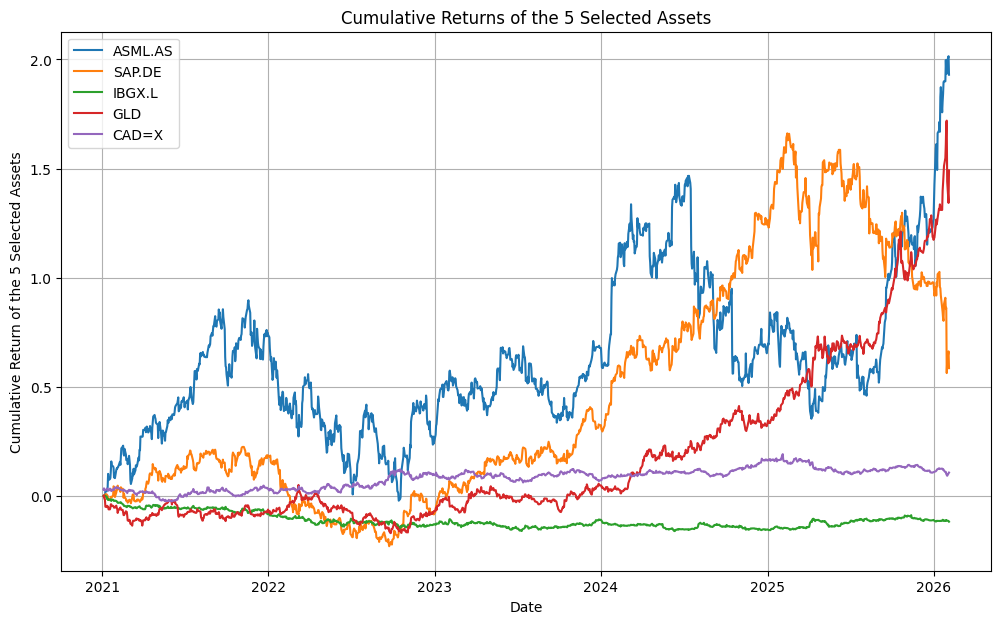

In [39]:
# Calculate portfolios' cumulative returns
cumulative_returns = (1 + portfolio_daily_returns_df).cumprod() - 1

print("--Expected cumulative returns for Equal-Weighted Portfolio --")
print(cumulative_returns)
print("")

# Visualize cumulative returns
plt.figure(figsize=(12, 7))
plt.plot(cumulative_returns.index, cumulative_returns['ASML.AS'], label='ASML.AS')
plt.plot(cumulative_returns.index, cumulative_returns['SAP.DE'], label='SAP.DE')
plt.plot(cumulative_returns.index, cumulative_returns['IBGX.L'], label='IBGX.L')
plt.plot(cumulative_returns.index, cumulative_returns['GLD'], label='GLD')
plt.plot(cumulative_returns.index, cumulative_returns['CAD=X'], label='CAD=X')
plt.title('Cumulative Returns of the 5 Selected Assets')
plt.xlabel('Date')
plt.ylabel('Cumulative Return of the 5 Selected Assets')
plt.legend()
plt.grid(True)
plt.show()

##Equal-Weighted portfolios' Rolling Volatility (60-day window)

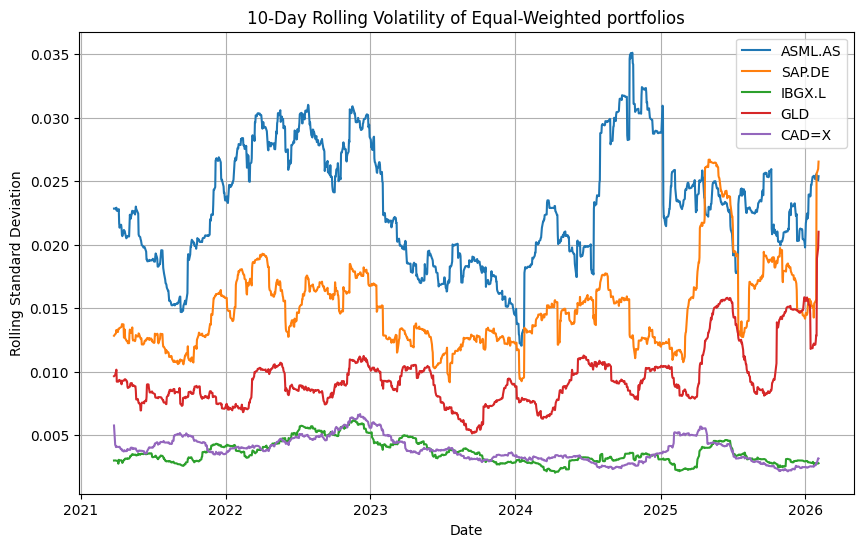

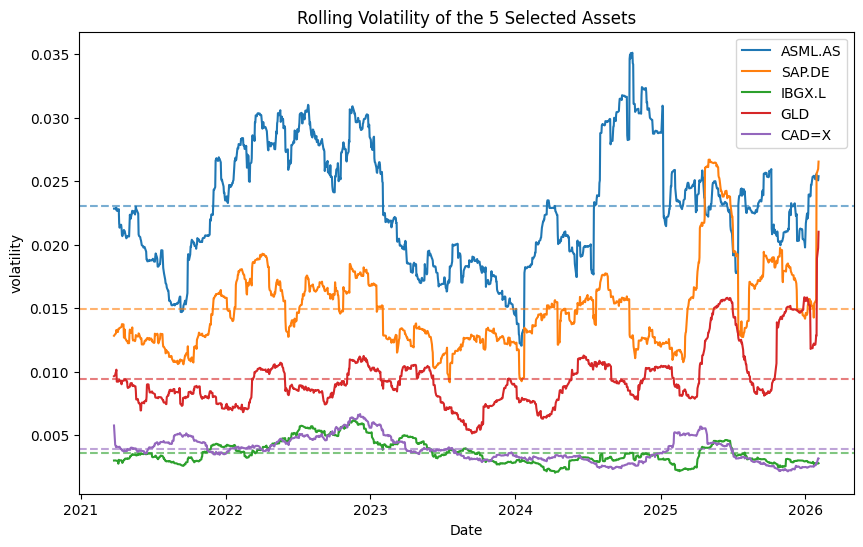

In [40]:
# Calculate 60-day rolling volatility (standard deviation)
rolling_volatility = portfolio_daily_returns_df.rolling(window=60).std()

# Visualize rolling volatility
plt.figure(figsize=(10, 6))
plt.plot(rolling_volatility.index, rolling_volatility['ASML.AS'], label='ASML.AS')
plt.plot(rolling_volatility.index, rolling_volatility['SAP.DE'], label='SAP.DE')
plt.plot(rolling_volatility.index, rolling_volatility['IBGX.L'], label='IBGX.L')
plt.plot(rolling_volatility.index, rolling_volatility['GLD'], label='GLD')
plt.plot(rolling_volatility.index, rolling_volatility['CAD=X'], label='CAD=X')
plt.title('10-Day Rolling Volatility of Equal-Weighted portfolios')
plt.xlabel('Date')
plt.ylabel('Rolling Standard Deviation')
plt.legend()
plt.grid(True)
plt.show()


# Calculate average volatility
avg_volatility = rolling_volatility.mean()

# Plot with average volatility(with colours)
plt.figure(figsize=(10, 6))

line, = plt.plot(rolling_volatility.index, rolling_volatility['ASML.AS'], label='ASML.AS')
plt.axhline(avg_volatility ['ASML.AS'], color = line.get_color(), linestyle='--', alpha = 0.6)

line, = plt.plot(rolling_volatility.index,rolling_volatility['SAP.DE'],label='SAP.DE')
plt.axhline(avg_volatility['SAP.DE'],  color = line.get_color(), linestyle='--', alpha = 0.6)

line, = plt.plot(rolling_volatility.index, rolling_volatility['IBGX.L'], label='IBGX.L')
plt.axhline(avg_volatility['IBGX.L'], color = line.get_color(), linestyle='--', alpha = 0.6)

line, = plt.plot(rolling_volatility.index, rolling_volatility['GLD'], label='GLD')
plt.axhline(avg_volatility['GLD'], color = line.get_color(), linestyle='--', alpha = 0.6)

line, = plt.plot(rolling_volatility.index, rolling_volatility['CAD=X'], label='CAD=X')
plt.axhline(avg_volatility['CAD=X'], color = line.get_color(), linestyle='--', alpha = 0.6)

plt.title('Rolling Volatility of the 5 Selected Assets')
plt.xlabel('Date')
plt.ylabel('volatility')
plt.legend()
plt.show()


##2.Dynamic-weighted portfolio: Weightings adjust over time

*   Define weight:
(momentum trading strategy: assets that have performed well historically are given higher weightings, with the specific weightings determined by their cumulative returns over a past period.)

*   Define rolling days:The 60-day period (approximately three months of trading days) is employed to capture medium-term volatility trends. A shorter window (such as 10 days) would result in overly volatile and unstable weighting changes, while a longer window (such as 252 days) would prove excessively sluggish in its response.So,60 days represents a commonly adopted compromise.

*   Calculate portfolio return (Daily returns, average returns, expected returns, annualized returns, volatility(variance + standard deviation), cumulative returns)





Gain insight into individual stock performance and overall market conditions to inform dynamic weighting decisions.
*   Primitive momentum curve
*   Sum of absolute momenta
*   Draw all the lines together




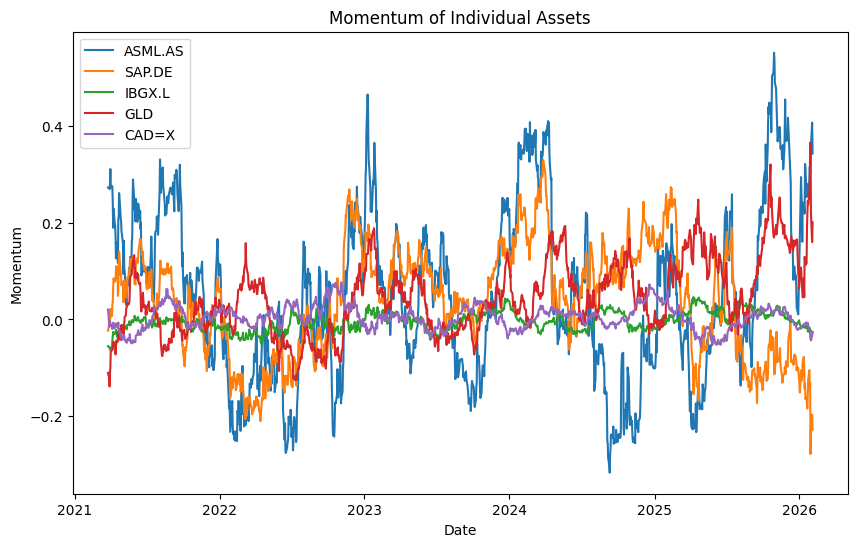

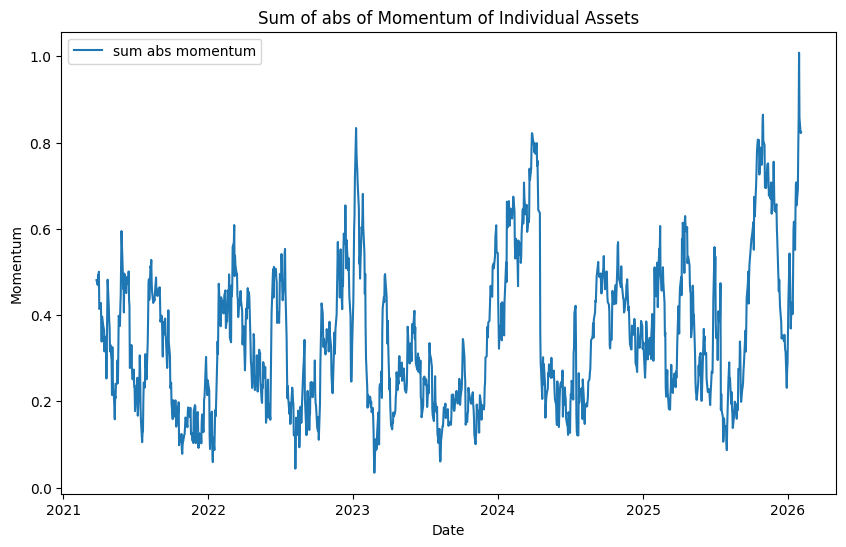

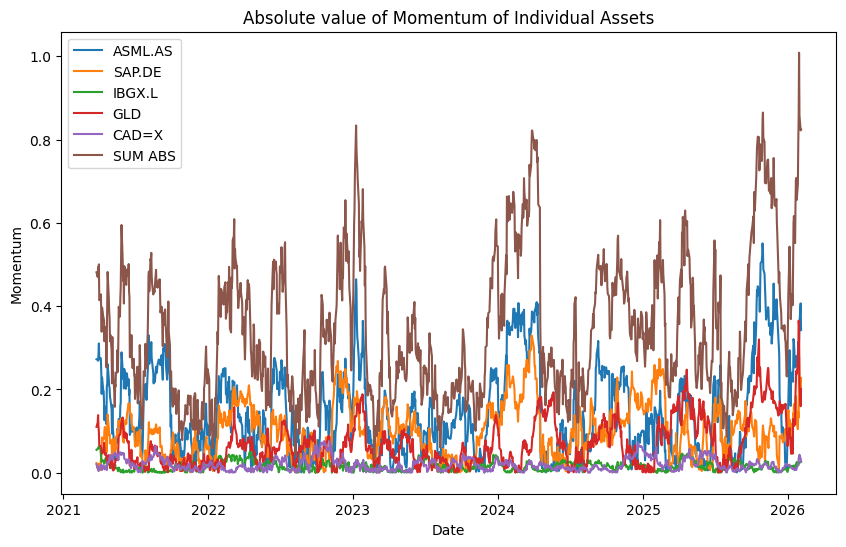

In [41]:
# Momentum data(60-day price return as signal:The cumulative return is obtained by multiplying the daily returns over 60 days, and subtracting 1 gives the total increase or decrease over the 60 days.)
momentum_df  = (1 + portfolio_daily_returns_df).rolling(window=60).apply(lambda x: x.prod() - 1).dropna()

# plot 1:Individual asset momentum

plt.figure(figsize=(10,6))
for stock_ticker in momentum_df.columns:
  plt.plot(momentum_df.index, momentum_df[stock_ticker], label=stock_ticker)


plt.title("Momentum of Individual Assets")
plt.xlabel("Date")
plt.ylabel("Momentum")
plt.legend()
plt.show()

# plot 2:Sum of abs momentum
plt.figure(figsize=(10,6))
plt.plot(momentum_df.index, momentum_df.abs().sum(axis=1), label="sum abs momentum")

plt.title("Sum of abs of Momentum of Individual Assets")
plt.xlabel("Date")
plt.ylabel("Momentum")
plt.legend()
plt.show()

# plot 3:Everything together
plt.figure(figsize=(10,6))
plt.plot(momentum_df.index,momentum_df["ASML.AS"].abs(),label = "ASML.AS")
plt.plot(momentum_df.index,momentum_df["SAP.DE"].abs(),label = "SAP.DE")
plt.plot(momentum_df.index,momentum_df["IBGX.L"].abs(),label = "IBGX.L")
plt.plot(momentum_df.index,momentum_df["GLD"].abs(),label = "GLD")
plt.plot(momentum_df.index,momentum_df["CAD=X"].abs(),label = "CAD=X")
plt.plot(momentum_df.index,momentum_df.abs().sum(axis=1),label = "SUM ABS")
plt.title("Absolute value of Momentum of Individual Assets")
plt.xlabel("Date")
plt.ylabel("Momentum")
plt.legend()
plt.show()

##Calculate momentum weighting


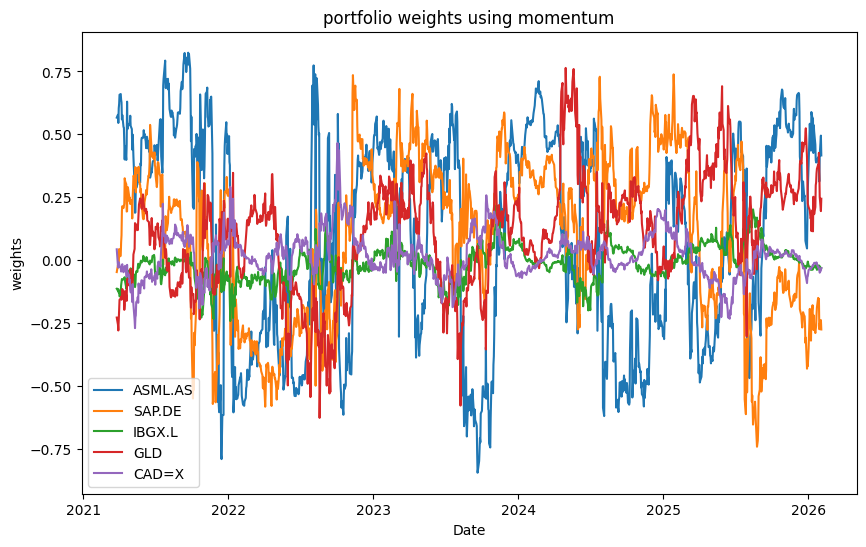

In [42]:
# Convert absolute momentum into weights (summing to 1)
from matplotlib import figure
momentum_weights = momentum_df.div(momentum_df.abs().sum(axis=1), axis=0)


# weights plot
plt.figure(figsize=(10,6))
plt.plot(momentum_weights.index,momentum_weights["ASML.AS"], label= "ASML.AS")
plt.plot(momentum_weights.index,momentum_weights["SAP.DE"], label = "SAP.DE")
plt.plot(momentum_weights.index,momentum_weights["IBGX.L"], label = "IBGX.L")
plt.plot(momentum_weights.index,momentum_weights["GLD"], label = "GLD")
plt.plot(momentum_weights.index,momentum_weights["CAD=X"], label = "CAD=X")
plt.title("portfolio weights using momentum")
plt.xlabel("Date")
plt.ylabel("weights")
plt.legend()
plt.show()


##Long-only momentum
#### Assets with negative momentum also receive negative weightings, implying a short position in that asset. But as we require the sum of weightings equal to 1 and all values to be positive, the absolute values （long-only） must be calculated.

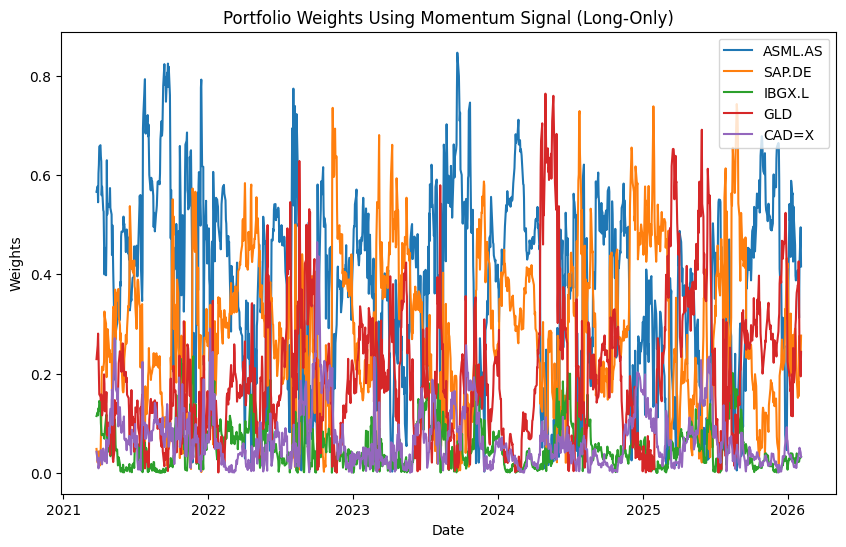

Date
2021-03-26    1.0
2021-03-29    1.0
2021-03-30    1.0
2021-03-31    1.0
2021-04-01    1.0
dtype: float64


In [43]:
# Only long: use absolute momentum as weights
abs_momentum = momentum_df.abs()
momentum_weights = abs_momentum.div(abs_momentum.sum(axis=1), axis=0)

# weights plot
plt.figure(figsize=(10, 6))
for ticker in momentum_weights.columns:
    plt.plot(momentum_weights.index, momentum_weights[ticker], label=ticker)

plt.title("Portfolio Weights Using Momentum Signal (Long-Only)")
plt.xlabel("Date")
plt.ylabel("Weights")
plt.legend()
plt.show()

# Verify that the weighted sum equals 1
print(momentum_weights.sum(axis=1).head())

The weight fluctuates sharply, almost changing every day. Which indicats that the momentum signal is highly sensitive to short-term price changes, leading to frequent portfolio adjustments. Our dynamic portfolio adopts a long-only dynamic weighting strategy based on momentum. Thus the result graph shows that the weights are all between 0 and 1. The weight of each asset is proportional to its 60-day cumulative absolute return and is standardized to make the sum of all weights equal to 1.

The assets with stronger recent price momentum will receive higher allocations. **ASML.AS** and **GLD** usually dominate the portfolio, often reaching weights of 0.6-0.8. This indicates that these two assets have the strongest momentum signals, causing the strategy is heavily concentrated on them. In contrast, the weights of **IBGX.L**and **CAD=X** are consistently close to 0, which suggesting that the momentum signals of bonds and foreign exchange are very weak, so they barely participate in the portfolio.


###Calculate the average proportion of dynamic weights to obtain the average weight of each asset in the whole time period.
Although it changes every day, the average value can represent the overall tendency, which is convenient for subsequent MVaR and CVaR decomposition

In [44]:
# Average weights for Momentum portfolio
avg_momentum_weights = momentum_weights.mean()

print("Average Momentum Weights:")
for ticker, weight in avg_momentum_weights.items():
    print(f"  {ticker}: {weight:.5%}")

Average Momentum Weights:
  ASML.AS: 38.81516%
  SAP.DE: 28.82274%
  IBGX.L: 5.44392%
  GLD: 20.32433%
  CAD=X: 6.59385%


##Calculate portfolio return





Lagged Momentum Weights (head):
             ASML.AS    SAP.DE    IBGX.L       GLD     CAD=X
Date                                                        
2021-03-29  0.566099  0.048152  0.114344  0.229011  0.042393
2021-03-30  0.577297  0.020602  0.122138  0.256906  0.023058
2021-03-31  0.544959  0.028559  0.115833  0.280422  0.030227
2021-04-01  0.603439  0.021401  0.130058  0.236045  0.009056
2021-04-02  0.620590  0.043221  0.125338  0.194896  0.015956
2021-04-05  0.657128  0.013642  0.144792  0.158211  0.026228
2021-04-06  0.659944  0.016703  0.138702  0.153292  0.031359
2021-04-07  0.637542  0.069804  0.100489  0.146222  0.045943
2021-04-08  0.626608  0.098094  0.089459  0.158125  0.027713
2021-04-09  0.559044  0.195636  0.075924  0.149527  0.019869

Momentum Portfolio Daily Returns (head):
Date
2021-01-01    0.0
2021-01-04    0.0
2021-01-05    0.0
2021-01-06    0.0
2021-01-07    0.0
dtype: float64

Daily Average Return: 0.06604%
Annualised Return: 18.09942%
Annualised Volatility: 

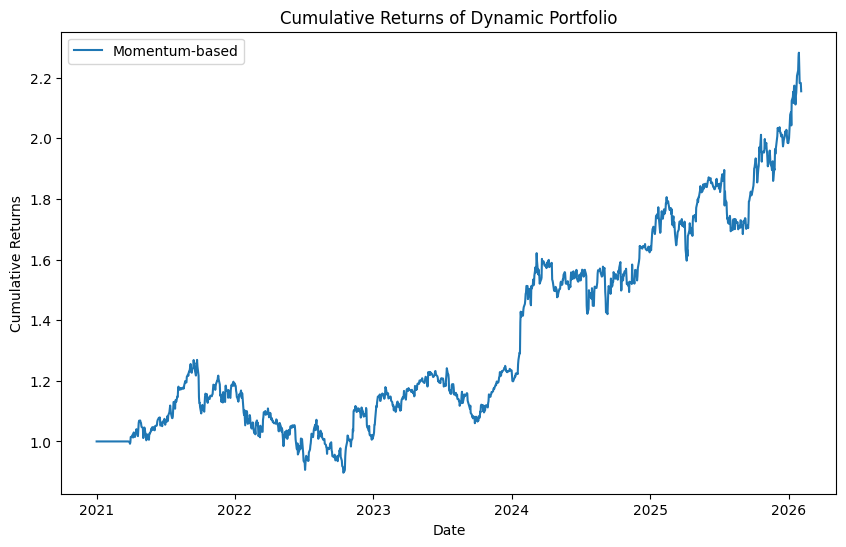

In [45]:
# How to calculate portfolio returns（One day's delay to avoid forward-looking bias）
momentum_weights_lagged_df = momentum_weights.shift(1)# we don't have today's values yet so we need to momentum_weights_lagged_df

# Calculate Daily Portfolio Returns
portfolio_daily_returns_momentum_df =(momentum_weights_lagged_df * portfolio_daily_returns_df).sum(axis=1)
print("Lagged Momentum Weights (head):")
print(momentum_weights_lagged_df.dropna().head(10))
print("\nMomentum Portfolio Daily Returns (head):")
print(portfolio_daily_returns_momentum_df.head(5))

# Average daily return
momentum_mean_return = portfolio_daily_returns_momentum_df.mean()
print(f"\nDaily Average Return: {momentum_mean_return:.5%}")

# Annualised return
momentum_annualized_return = (1 + momentum_mean_return) ** 252 -1 # Use AI which taking into account the compound interest effect, it more closely aligns with actual investment scenarios.
print(f"Annualised Return: {momentum_annualized_return:.5%}")

# Annualised volatility
momentum_annualized_vol = portfolio_daily_returns_momentum_df.std() * np.sqrt(252)
print(f"Annualised Volatility: {momentum_annualized_vol:.5%}")

# Calculate cumulative returns
cumulative_portfolio_returns_momentum_df = (1 + portfolio_daily_returns_momentum_df).cumprod()

plt.figure(figsize=(10, 6))
plt.plot(cumulative_portfolio_returns_momentum_df.index, cumulative_portfolio_returns_momentum_df, label='Momentum-based')
plt.title("Cumulative Returns of Dynamic Portfolio")
plt.xlabel ("Date")
plt.ylabel ("Cumulative Returns")
plt.legend()
plt.show()


##Comparison of Equal-Weight vs Dynamic-weight Portfolio Construction



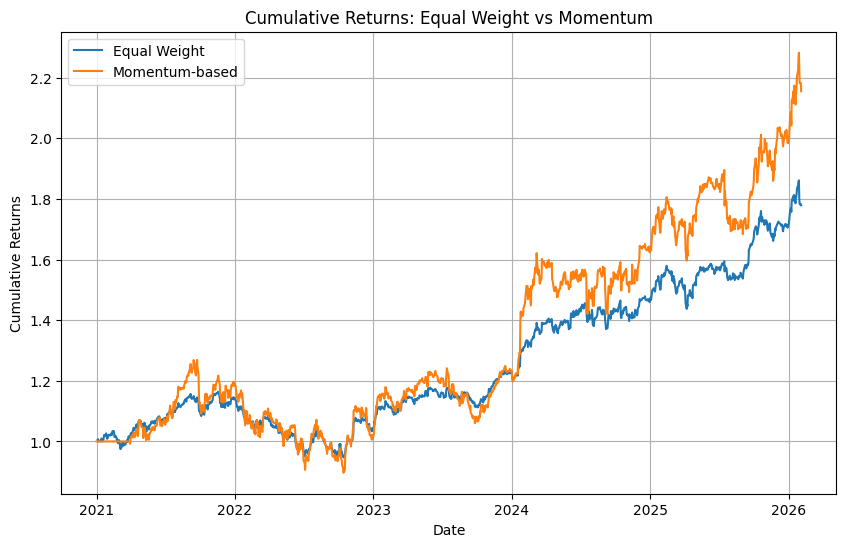

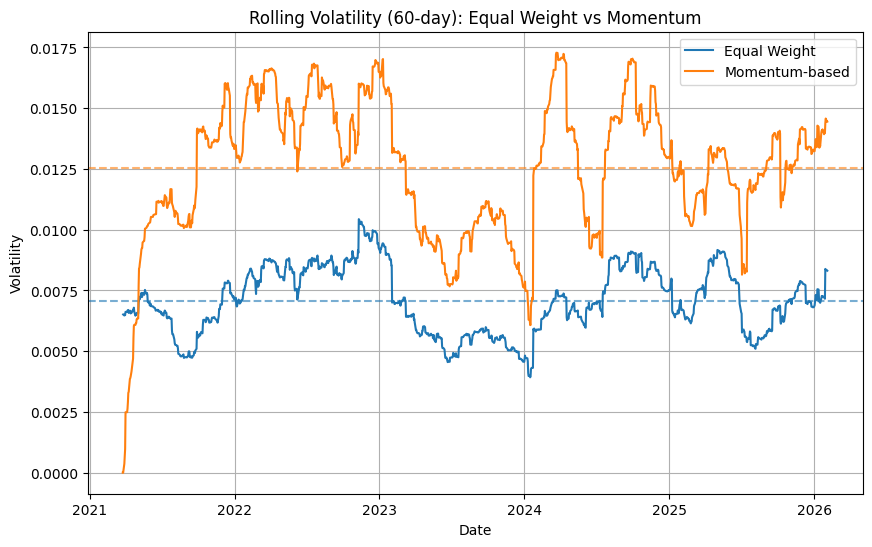

Metric                    Equal Weight     Momentum
Annualised Return             12.3158%     18.0994%
Annualised Volatility         11.4622%     20.2355%
Cumulative Return             77.9279%    115.5260%


In [46]:
# First make sure equal weight cumulative returns is calculated
equal_cumulative_returns = (1 + portfolio_equal_weighted_daily_returns).cumprod()
equal_portfolio_rolling_vol = portfolio_equal_weighted_daily_returns.rolling(window=60).std()

# Compare cumulative returns: Dynamic (Momentum) Portfolio vs Equal-Weighted Portfolio
plt.figure(figsize=(10, 6))
plt.plot(equal_cumulative_returns.index, equal_cumulative_returns, label='Equal Weight')
plt.plot(cumulative_portfolio_returns_momentum_df.index, cumulative_portfolio_returns_momentum_df, label='Momentum-based')
plt.title("Cumulative Returns: Equal Weight vs Momentum")
plt.xlabel("Date")
plt.ylabel("Cumulative Returns")
plt.legend()
plt.grid(True)
plt.show()

# Rolling Volatility Comparison
momentum_rolling_vol = portfolio_daily_returns_momentum_df.rolling(window=60).std()

plt.figure(figsize=(10, 6))
# average line
line1, = plt.plot(equal_portfolio_rolling_vol.index, equal_portfolio_rolling_vol, label='Equal Weight')
plt.axhline(equal_portfolio_rolling_vol.mean(), color=line1.get_color(), linestyle='--', alpha=0.6)
line2, = plt.plot(momentum_rolling_vol.index, momentum_rolling_vol, label='Momentum-based')
plt.axhline(momentum_rolling_vol.mean(), color=line2.get_color(), linestyle='--', alpha=0.6)

plt.title("Rolling Volatility (60-day): Equal Weight vs Momentum")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()

#Summary Comparison Table (used ai)
equal_cumulative_final = equal_cumulative_returns.iloc[-1] - 1
momentum_cumulative_final = cumulative_portfolio_returns_momentum_df.iloc[-1] - 1
equal_annualized_return = (1 + portfolio_equal_weighted_daily_returns.mean()) ** 252 - 1
equal_annualized_vol = portfolio_equal_weighted_daily_returns.std() * np.sqrt(252)

print("=" * 50)
print(f"{'Metric':<25} {'Equal Weight':>12} {'Momentum':>12}")
print("=" * 50)
print(f"{'Annualised Return':<25} {equal_annualized_return:>12.4%} {momentum_annualized_return:>12.4%}")
print(f"{'Annualised Volatility':<25} {equal_annualized_vol:>12.4%} {momentum_annualized_vol:>12.4%}")
print(f"{'Cumulative Return':<25} {equal_cumulative_final:>12.4%} {momentum_cumulative_final:>12.4%}")
print("=" * 50)

##**Comparative analysis**
### Cumulative Return Rate:
Throughout the entire period, the momentum-based portfolio outperformed the equal-weighted portfolio. As shown in the summary table, their cumulative return rates were 115.53% and 77.93% respectively. Between 2021 and 2023, the trends of these two portfolios were quite similar, almost overlapping. However, starting from 2024, they began to diverge significantly. Although both portforlios continued to show a steady upward trend, the momentum portfolio gradually pulled ahead of
the equal-weighted one. Its growth also appeared to accelerate and widening the gap during the subsequent period.

### Rolling Volatility:
Throughout the period, the volatility of the momentum portfolio remained consistently higher than that of the equal-weighted portfolio. The annualized volatilities of the momentum strategy reached 20.24%,while the equalequal- weighted portfolio shows a much lower level of 11.46%. The average volatility line of the momentum portfolio (the yellow dotted line at 0.00125) was also higher than that of the equal-weighted portfolio (the blue dotted line about 0.0073). As a result, the portfolio became more concentrated, which increased its sensitivity to price fluctuations. In contrast, the equal-weighted portfolio distributed capital evenly across all five assets, providing better diversification and therefore lower overall volatility.

### Overall:
The momentum strategy delivered a higher return rate (18.10% annualized compared to 12.32%) and a stronger cumulative performance (115.53% compared to 77.93%), but at the cost of significantly higher volatility. The equal-weighted strategy offered a more stable and lower-risk exposure, while the momentum strategy rewarded investors who could tolerate greater short-term fluctuations in exchange for higher long-term gains.

#**Part 1C - Risk Measures**


========== Monte Carlo: Equal Weight ==========

Portfolio Expected Return: 0.0461%
Portfolio Variance: 0.000052

Portfolio VaR at 95%: 0.002342
Portfolio VaR at 99%: 0.003321


========== Monte Carlo: Dynamic Weight ==========

Portfolio Expected Return: 0.0712%
Portfolio Variance: 0.000152

Portfolio VaR at 95%: 0.004019
Portfolio VaR at 99%: 0.005669



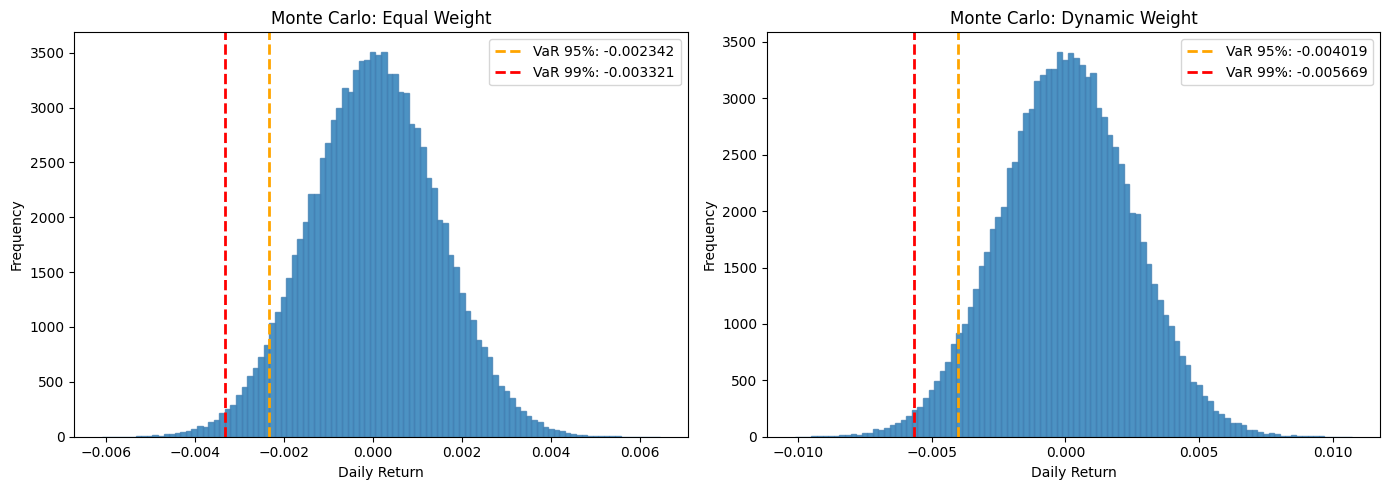

In [47]:
# ========= Monte Carlo Simulation ========= #

n_simulations = 100000 # Simulate 100000 random scenarios
np.random.seed(42)
n_days = 10/252 # Forecast horizon (10 day)

returns_assets = portfolio_daily_returns_df_cleaned.copy() # Use the cleaned return data

mu = returns_assets.mean().round(6) # Mean
Sigma = returns_assets.cov().round(6) # Covariance

# ========== Equal Weight Portfolio ========== #
print("\n========== Monte Carlo: Equal Weight ==========\n")

w_equal = equal_weights
mu_p_equal = np.dot(w_equal, mu)
variance_p_equal = np.dot(w_equal.T, np.dot(Sigma, w_equal))

print(f"Portfolio Expected Return: {mu_p_equal:.4%}")
print(f"Portfolio Variance: {variance_p_equal:.6f}")
print("")

# Multivariate normal simulation
simulated_returns_equal = np.random.multivariate_normal(
    mu * n_days,
    Sigma * n_days,
    n_simulations
)

# Simulated of Portfolio Return
portfolio_simulated_equal = simulated_returns_equal @ w_equal

# VaR 95%
VaR_equal_MC_95 = -np.percentile(portfolio_simulated_equal, 5)

# VaR 99%
VaR_equal_MC_99 = -np.percentile(portfolio_simulated_equal, 1)

print(f"Portfolio VaR at 95%: {VaR_equal_MC_95:.6f}")
print(f"Portfolio VaR at 99%: {VaR_equal_MC_99:.6f}")
print("")


# ========== Dynamic Weight ========== #
print("\n========== Monte Carlo: Dynamic Weight ==========\n")

w_mom = avg_momentum_weights.values
mu_p_mom = np.dot(w_mom, mu)
variance_p_mom = np.dot(w_mom.T, np.dot(Sigma, w_mom))

print(f"Portfolio Expected Return: {mu_p_mom:.4%}")
print(f"Portfolio Variance: {variance_p_mom:.6f}")
print("")

# Multivariate normal simulation
simulated_returns_mom = np.random.multivariate_normal(
    mu * n_days,
    Sigma * n_days,
    n_simulations
)

# Simulated of Portfolio Return
portfolio_simulated_mom = simulated_returns_mom @ w_mom

# VaR 95%
VaR_mom_MC_95 = -np.percentile(portfolio_simulated_mom, 5)

# VaR 99%
VaR_mom_MC_99 = -np.percentile(portfolio_simulated_mom, 1)

print(f"Portfolio VaR at 95%: {VaR_mom_MC_95:.6f}")
print(f"Portfolio VaR at 99%: {VaR_mom_MC_99:.6f}")
print("")

# ========== Graphs ========== #
def plot_mc_var_hist(ax, portfolio_simulated, title):

    # Calculate Tails
    q05 = np.percentile(portfolio_simulated, 5)   # VaR 95%
    q01 = np.percentile(portfolio_simulated, 1)   # VaR 99%

    # Normal Distribution
    ax.hist(portfolio_simulated, bins=100, edgecolor='steelblue', alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Daily Return")
    ax.set_ylabel("Frequency")

    ax.axvline(q05, linestyle="--", linewidth=2, color="orange",
               label=f"VaR 95%: {q05:.6f}")
    ax.axvline(q01, linestyle="--", linewidth=2, color="red",
               label=f"VaR 99%: {q01:.6f}")

    ax.legend(loc="upper right")
    ax.grid(False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_mc_var_hist(
    axes[0],
    portfolio_simulated_equal,
    "Monte Carlo: Equal Weight"
)

plot_mc_var_hist(
    axes[1],
    portfolio_simulated_mom,
    "Monte Carlo: Dynamic Weight"
)

plt.tight_layout()
plt.show()



##**Explanations**
###1. Method
This section estimates the mean vector μ and covariance matrix
Σ from historical daily returns of the final chosen assets (ASML.AS, SAP.DE, IBGX.L, GLD, CAD=X). Conduct 100,000 scenario simulations over a period of 10 trading days (10/252 years) to obtain the future 10 day return distribution of the portfolio, and compute VaR at 95% and 99%.

###2. Results of  Equal-weight Portfolio
VaR (95%)=0.002342 indicates that, assuming the model assumptions are true, there is a probability of approximately 95% that the portfolio loss will not exceed 0.2342% within the next 10 trading days; But there is still a probability of about 5% for larger losses to occur.
VaR (99%) corresponds to a more extreme tail risk threshold (approximately 0.3321%).

###3. Results of  Dynamic-weight Portfolio
The Monte Carlo for the dynamic strategy uses average momentum weights  rather than fully time-varying daily rebalancing.
Compared to the equal-weight portfolio, the variance of the dynamic-weight portfolio increased from 0.000052 to 0.000152, which is about 3 times, corresponding to a VaR (95%) increase from 0.2342% to 0.4019%, and a VaR (99%) increase from 0.3321% to 0.5669%. This indicates that under the average exposure profile, dynamic-weight portfolio provides higher expected returns (0.0712% vs 0.0461%), but at materially higher tail-loss thresholds.


##**Limitations**
###1. Normality Assumption may Understate Extreme Tails
This simulation uses a multivariate normal distribution to generate returns. However, Real-world returns often suffer from fat tails, skewness, and jumps. Under this framework, even if equity assets with high volatility (such as ASML. AS) are included, the 10-day VaR (99%) is still only 0.3321% (equal-weight) and 0.5669% (dynamic-weight), which may be "moderate" in magnitude and thus pose a risk of underestimating the probability and magnitude of extreme losses.


###2. Parameter Stability
Both μ and ∑ are estimated from historical samples and used for predicting the next 10 days, implying that 'future statistical features are consistent with the past'. But when the correlation increases or the volatility structure changes during the stress period, the combination variance and VaR may significantly shift upwards. Especially in the case where the risk is highly concentrated in ASML.AS, once a structural shock occurs, historical covariance may not be able to characterize the true tail co-movements.


###3. VaR Ignores Loss Severity
VaR only provides quantile thresholds, but does not provide information on the average loss after exceeding this threshold. Therefore, in tail risk assessment, VaR needs to be combined with other indicators to better capture tail-loss severity.



#**Part 1D - Risk Decomposition**

##**95% Confidence Interval**

In [48]:
from scipy.stats import norm

# Compute Covariance and Mean
returns_assets = portfolio_daily_returns_df_cleaned.copy() # Use the cleaned return data

mu = returns_assets.mean().round(6) # Mean
Sigma = returns_assets.cov().round(6) # Covariance

print("Covariance of Final Assets\n")
print(Sigma)
print("")
print("Mean of Final Assets\n")
print(mu)
print("")
print("")


alpha_95 = 0.95 # 95% Confidence interval
z_95 = norm.ppf(1 - alpha_95)  # Z-value
print(f"alpha={alpha_95:.2f}, Horizon={n_days:.2f}, z={z_95:.6f}")
print("")


# ========== Equal Weight ========= #
print("\n========== Equal Weight ==========")

w_equal = equal_weights
mu_p_equal = np.dot(w_equal, mu)
variance_p_equal = np.dot(w_equal.T, np.dot(Sigma, w_equal))
VaR_equal_95 = -(mu_p_equal * n_days + z_95 * np.sqrt(variance_p_equal * n_days))

print("\n-----Portfolio 1-----")
print(f"Portfolio Expected Return: {mu_p_equal:.4%}")
print(f"Portfolio Variance: {variance_p_equal:.6f}")
print(f"Portfolio VaR (99%): {VaR_equal_95:.6f}")
print("")

# Compute Beta
beta_equal = np.dot(Sigma, w_equal) / (variance_p_equal)

beta_table_equal = pd.DataFrame({
    "Asset": Final_assets,
    "Beta": beta_equal
}).set_index("Asset") # Set 'Asset' as index

print("\n-----Betas-----")
print(beta_table_equal)
print("")

# Individual VaR
Individual_VaR_equal_95 = -(mu * n_days + z_95 * np.sqrt(n_days * np.diag(Sigma)))
Undiversified_VaR_equal_95 = Individual_VaR_equal_95.sum()

# Marginal VaR
MVaR_equal_95 = VaR_equal_95 * beta_equal

# Component VaR
CVaR_equal_95 = w_equal * MVaR_equal_95
Diversified_VaR_equal_95 = CVaR_equal_95.sum()

# CVaR%
CVaR_percent_equal_95 = CVaR_equal_95 / VaR_equal_95

table_equal_95 = pd.DataFrame({
    "Weight": w_equal,
    "Individual VaR": Individual_VaR_equal_95,
    "MVaR": MVaR_equal_95,
    "CVaR": CVaR_equal_95,
    "CVaR%": CVaR_percent_equal_95
},index=Final_assets)


table_equal_95["Weight"] = table_equal_95["Weight"].map("{:.2%}".format)
table_equal_95["CVaR%"] = table_equal_95["CVaR%"].map("{:.2%}".format)

df_equal_95 = table_equal_95.copy()
# Undiversified VaR is only displayed at the bottom of the column of individual var
row_undiv_equal_95 = {col: np.nan for col in df_equal_95.columns}
row_undiv_equal_95["Individual VaR"] = Undiversified_VaR_equal_95

# Diversified VaR is only displayed at the bottom of the CVaR column
row_div_equal_95 = {col: np.nan for col in df_equal_95.columns}
row_div_equal_95["CVaR"] = Diversified_VaR_equal_95

df_out_equal_95 = pd.concat([df_equal_95, pd.DataFrame([row_undiv_equal_95, row_div_equal_95],index=["Undiversified VaR", "Diversified VaR"])])
df_out_equal_95 = df_out_equal_95.fillna("")

# Sum CVaR%
sum_cvar_equal_percent_95 = CVaR_percent_equal_95.sum()

print("\n***** Risk decomposition table (95%) of Equal-weighted Portfolio *****\n")
print(df_out_equal_95)
print("")
print("CVaR% Sum: {:.2%}".format(sum_cvar_equal_percent_95))
print("")




# ========== Dynamic Weight ============= #
print("\n========== Dynamic Weight ==========\n")

w_mom = avg_momentum_weights.values
mu_p_mom = np.dot(w_mom, mu)
variance_p_mom = np.dot(w_mom.T, np.dot(Sigma, w_mom))
VaR_mom_95 = -(mu_p_mom * n_days + z_95 * np.sqrt(variance_p_mom * n_days))
print("-----Portfolio 2-----")
print(f"Portfolio Expected Return: {mu_p_mom:.4%}")
print(f"Portfolio Variance: {variance_p_mom:.6f}")
print(f"Portfolio VaR (95%): {VaR_mom_95:.6f}")
print("")

# Conmpute Beta
beta_mom = np.dot(Sigma, w_mom) / (variance_p_mom)

beta_table_mom = pd.DataFrame({
    "Asset": Final_assets,
    "Beta": beta_mom
}).set_index("Asset") # Set 'Asset' as index

print("\n-----Betas-----")
print(beta_table_mom)
print("")

# Individual VaR
Individual_VaR_mom_95 = -(mu * n_days + z_95 * np.sqrt(n_days * np.diag(Sigma)))
Undiversified_VaR_mom_95 = Individual_VaR_mom_95.sum()

# Marginal VaR
MVaR_mom_95 = VaR_mom_95 * beta_mom

# Component VaR
CVaR_mom_95 = w_mom * MVaR_mom_95
Diversified_VaR_mom_95 = CVaR_mom_95.sum()

# CVaR%
CVaR_percent_mom_95 = CVaR_mom_95 / VaR_mom_95

table_mom_95 = pd.DataFrame({
    "Weight": w_mom,
    "Individual VaR": Individual_VaR_mom_95,
    "MVaR": MVaR_mom_95,
    "CVaR": CVaR_mom_95,
    "CVaR%": CVaR_percent_mom_95
},index=Final_assets)

table_mom_95["Weight"] = table_mom_95["Weight"].map("{:.2%}".format)
table_mom_95["CVaR%"] = table_mom_95["CVaR%"].map("{:.2%}".format)

df_mom_95 = table_mom_95.copy()
# Undiversified VaR is only displayed at the bottom of the column of individual var
row_undiv_mom_95 = {col: np.nan for col in df_mom_95.columns}
row_undiv_mom_95["Individual VaR"] = Undiversified_VaR_mom_95

# Diversified VaR is only displayed at the bottom of the CVaR column
row_div_mom_95 = {col: np.nan for col in df_mom_95.columns}
row_div_mom_95["CVaR"] = Diversified_VaR_mom_95

df_out_mom_95 = pd.concat([df_mom_95, pd.DataFrame([row_undiv_mom_95, row_div_mom_95],index=["Undiversified VaR", "Diversified VaR"])])
df_out_mom_95 = df_out_mom_95.fillna("")


# Sum CVaR%
sum_cvar_mom_percent_95 = CVaR_percent_mom_95.sum()

print("\n***** Risk decomposition table (95%) of Dynamic-weighted Portfolio *****\n")
print(df_out_mom_95)
print("")
print("CVaR% Sum: {:.2%}".format(sum_cvar_mom_percent_95))

Covariance of Final Assets

          ASML.AS    SAP.DE    IBGX.L       GLD     CAD=X
ASML.AS  0.000553  0.000183 -0.000009  0.000017 -0.000005
SAP.DE   0.000183  0.000253 -0.000005  0.000000 -0.000003
IBGX.L  -0.000009 -0.000005  0.000014  0.000002  0.000000
GLD      0.000017  0.000000  0.000002  0.000108 -0.000000
CAD=X   -0.000005 -0.000003  0.000000 -0.000000  0.000016

Mean of Final Assets

ASML.AS    0.001089
SAP.DE     0.000475
IBGX.L    -0.000088
GLD        0.000744
CAD=X      0.000085
dtype: float64


alpha=0.95, Horizon=0.04, z=-1.644854


========== Equal Weight ==========

-----Portfolio 1-----
Portfolio Expected Return: 0.0461%
Portfolio Variance: 0.000052
Portfolio VaR (99%): 0.002348


-----Betas-----
             Beta
Asset            
ASML.AS  2.833589
SAP.DE   1.641104
IBGX.L   0.007669
GLD      0.486963
CAD=X    0.030675


***** Risk decomposition table (95%) of Equal-weighted Portfolio *****

                   Weight Individual VaR      MVaR      CVaR   CVaR%
ASML.

##**99% Confidence Interval**

In [49]:
# Compute Covariance and Mean
returns_assets = portfolio_daily_returns_df_cleaned.copy() # Use the cleaned return data

mu = returns_assets.mean().round(6) # Mean
Sigma = returns_assets.cov().round(6) # Covariance

print("Covariance of Final Assets\n")
print(Sigma)
print("")
print("Mean of Final Assets\n")
print(mu)
print("")
print("")


alpha_99 = 0.99 # 99% Confidence interval
z_99 = norm.ppf(1 - alpha_99)  # Z-value
print(f"alpha={alpha_99:.2f}, Horizon={n_days:.2f}, z={z_99:.6f}")
print("")




# ========== Equal Weight ========= #
print("\n========== Equal Weight ==========")

w_equal = equal_weights
mu_p_equal = np.dot(w_equal, mu)
variance_p_equal = np.dot(w_equal.T, np.dot(Sigma, w_equal))
VaR_equal_99 = -(mu_p_equal * n_days + z_99 * np.sqrt(variance_p_equal * n_days))

print("\n-----Portfolio 1-----")
print(f"Portfolio Expected Return: {mu_p_equal:.4%}")
print(f"Portfolio Variance: {variance_p_equal:.6f}")
print(f"Portfolio VaR (99%): {VaR_equal_99:.6f}")
print("")

# Compute Beta
beta_equal = np.dot(Sigma, w_equal) / (variance_p_equal)

beta_table_equal = pd.DataFrame({
    "Asset": Final_assets,
    "Beta": beta_equal
}).set_index("Asset") # Set 'Asset' as index

print("\n-----Betas-----")
print(beta_table_equal)
print("")

# Individual VaR
Individual_VaR_equal_99 = -(mu * n_days + z_99 * np.sqrt(n_days * np.diag(Sigma)))
Undiversified_VaR_equal_99 = Individual_VaR_equal_99.sum()

# Marginal VaR
MVaR_equal_99 = VaR_equal_99 * beta_equal

# Component VaR
CVaR_equal_99 = w_equal * MVaR_equal_99
Diversified_VaR_equal_99 = CVaR_equal_99.sum()

# CVaR%
CVaR_percent_equal_99 = CVaR_equal_99 / VaR_equal_99

table_equal_99 = pd.DataFrame({
    "Weight": w_equal,
    "Individual VaR": Individual_VaR_equal_99,
    "MVaR": MVaR_equal_99,
    "CVaR": CVaR_equal_99,
    "CVaR%": CVaR_percent_equal_99
},index=Final_assets)


table_equal_99["Weight"] = table_equal_99["Weight"].map("{:.2%}".format)
table_equal_99["CVaR%"] = table_equal_99["CVaR%"].map("{:.2%}".format)

df_equal_99 = table_equal_99.copy()
# Undiversified VaR is only displayed at the bottom of the column of individual var
row_undiv_equal_99 = {col: np.nan for col in df_equal_99.columns}
row_undiv_equal_99["Individual VaR"] = Undiversified_VaR_equal_99

# Diversified VaR is only displayed at the bottom of the CVaR column
row_div_equal_99 = {col: np.nan for col in df_equal_99.columns}
row_div_equal_99["CVaR"] = Diversified_VaR_equal_99

df_out_equal_99 = pd.concat([df_equal_99, pd.DataFrame([row_undiv_equal_99, row_div_equal_99],index=["Undiversified VaR", "Diversified VaR"])])
df_out_equal_99 = df_out_equal_99.fillna("")

# Sum CVaR%
sum_cvar_equal_percent_99 = CVaR_percent_equal_99.sum()

print("\n***** Risk decomposition table (99%) of Equal-weighted Portfolio *****\n")
print(df_out_equal_99)
print("")
print("CVaR% Sum: {:.2%}".format(sum_cvar_equal_percent_99))
print("")




# ========== Dynamic Weight ============= #
print("\n========== Dynamic Weight ==========\n")

w_mom = avg_momentum_weights.values
mu_p_mom = np.dot(w_mom, mu)
variance_p_mom = np.dot(w_mom.T, np.dot(Sigma, w_mom))
VaR_mom_99 = -(mu_p_mom * n_days + z_99 * np.sqrt(variance_p_mom * n_days))
print("-----Portfolio 2-----")
print(f"Portfolio Expected Return: {mu_p_mom:.4%}")
print(f"Portfolio Variance: {variance_p_mom:.6f}")
print(f"Portfolio VaR (99%): {VaR_mom_99:.6f}")
print("")

# Conmpute Beta
beta_mom = np.dot(Sigma, w_mom) / (variance_p_mom)

beta_table_mom = pd.DataFrame({
    "Asset": Final_assets,
    "Beta": beta_mom
}).set_index("Asset") # Set 'Asset' as index

print("\n-----Betas-----")
print(beta_table_mom)
print("")

#Individual VaR
Individual_VaR_mom_99 = -(mu * n_days + z_99 * np.sqrt(n_days * np.diag(Sigma)))
Undiversified_VaR_mom_99 = Individual_VaR_mom_99.sum()

# Marginal VaR
MVaR_mom_99 = VaR_mom_99 * beta_mom

# Component VaR
CVaR_mom_99 = w_mom * MVaR_mom_99
Diversified_VaR_mom_99 = CVaR_mom_99.sum()

# CVaR%
CVaR_percent_mom_99 = CVaR_mom_99 / VaR_mom_99

table_mom_99 = pd.DataFrame({
    "Weight": w_mom,
    "Individual VaR": Individual_VaR_mom_99,
    "MVaR": MVaR_mom_99,
    "CVaR": CVaR_mom_99,
    "CVaR%": CVaR_percent_mom_99
},index=Final_assets)

table_mom_99["Weight"] = table_mom_99["Weight"].map("{:.2%}".format)
table_mom_99["CVaR%"] = table_mom_99["CVaR%"].map("{:.2%}".format)

df_mom_99 = table_mom_99.copy()
# Undiversified VaR is only displayed at the bottom of the column of individual var
row_undiv_mom = {col: np.nan for col in df_mom_99.columns}
row_undiv_mom["Individual VaR"] = Undiversified_VaR_mom_99

# Diversified VaR is only displayed at the bottom of the CVaR column
row_div_mom = {col: np.nan for col in df_mom_99.columns}
row_div_mom["CVaR"] = Diversified_VaR_mom_99

df_out_mom_99 = pd.concat([df_mom_99, pd.DataFrame([row_undiv_mom, row_div_mom],index=["Undiversified VaR", "Diversified VaR"])])
df_out_mom_99 = df_out_mom_99.fillna("")


#Sum CVaR%
sum_cvar_mom_percent_99 = CVaR_percent_mom_99.sum()

print("\n***** Risk decomposition table (99%) of Dynamic-weighted Portfolio *****\n")
print(df_out_mom_99)
print("")
print("CVaR% Sum: {:.2%}".format(sum_cvar_mom_percent_99))

Covariance of Final Assets

          ASML.AS    SAP.DE    IBGX.L       GLD     CAD=X
ASML.AS  0.000553  0.000183 -0.000009  0.000017 -0.000005
SAP.DE   0.000183  0.000253 -0.000005  0.000000 -0.000003
IBGX.L  -0.000009 -0.000005  0.000014  0.000002  0.000000
GLD      0.000017  0.000000  0.000002  0.000108 -0.000000
CAD=X   -0.000005 -0.000003  0.000000 -0.000000  0.000016

Mean of Final Assets

ASML.AS    0.001089
SAP.DE     0.000475
IBGX.L    -0.000088
GLD        0.000744
CAD=X      0.000085
dtype: float64


alpha=0.99, Horizon=0.04, z=-2.326348


========== Equal Weight ==========

-----Portfolio 1-----
Portfolio Expected Return: 0.0461%
Portfolio Variance: 0.000052
Portfolio VaR (99%): 0.003329


-----Betas-----
             Beta
Asset            
ASML.AS  2.833589
SAP.DE   1.641104
IBGX.L   0.007669
GLD      0.486963
CAD=X    0.030675


***** Risk decomposition table (99%) of Equal-weighted Portfolio *****

                   Weight Individual VaR      MVaR      CVaR   CVaR%
ASML.

##**Analysis**
###**1. Overall Risk Structure Comparison**
At 95% VaR level, the risk measurement reflects "conventional extreme volatility", while 99% VaR measures "tail extreme risk". From the results, at 99% VaR, the risk contribution is significantly more concentrated in high volatility technology assets (especially ASML.AS), while at 95% VaR, the risk distribution is relatively more balanced. This shows that in more extreme market situations, portfolio risk is more dependent on high beta and high volatility assets, and tail risk shows a stronger concentration.


###2. **ASML.AS**: Tail Risk Amplification
At 95% VaR, ASML is already the main source of risk, but at 99% VaR, its risk contribution significantly increases and Beta significantly improves. This indicates that ASML has a stronger loss amplification effect during extreme market downturns and exhibits a clear fat left-tail characteristic. As a semiconductor leader, its profits are highly sensitive to the global technology cycle and often experience more severe declines during market panic periods. Therefore, it bears a higher proportion of portfolio risk at a 99% confidence level.


###3. **SAP.DE**: Relatively Stable but Sector-Sensitive
The change in variation of SAP between 95% and 99% VaR is smaller than that of ASML, indicating that its tail risk amplification effect is relatively weak. However, as it belongs to the same technology sector as ASML, it will still be affected by industry systemic shocks under 99% extreme scenarios. This reflects the synergistic amplification effect of industry concentration risk in the tail scenario.


###4. **GLD**: Stronger Tail Hedging Effect
At 95% VaR, GLD contributes modest risk; At 99% VaR, its risk contribution further decreases, and even its relative proportion is smaller. This indicates that the correlation between gold and stocks further decreases under extreme market pressure, and may even exhibit a safe-haven inflows. Therefore, at a 99% confidence level, the diversified value of gold is more pronounced, providing a stronger buffering effect in tail-risk scenarios.


###5. **IBGX.L** and **CAD=X**: Negative Tail Covariance
At 95% VaR, the risk contribution of these two types of assets is close to zero; under 99% VaR, they may even show slightly negative contributions. This implies that in extreme left tail scenarios, they have negative covariance with the portfolio and can provide partial hedging effects when the market drops sharply. This feature is more pronounced at higher confidence levels, indicating that low correlation or foreign exchange assets have strategic significance in tail-risk management.


###**6. Comparing the Changes of Equal Weight and Dynamic Weight Portfolios at Different Confidence Levels**
At 95% VaR, the risk concentration of dynamic portfolios has exceeded that of weighted portfolios; At 99% VaR, this concentration further intensifies, and the proportion of ASML risk significantly increases. This suggests that although dynamic weighted strategies enhance the potential for returns, they can amplify tail exposure under extreme risks, making the portfolio highly dependent on a single high growth asset. Therefore, dynamic strategies exhibit stronger tail concentration risk at a 99% confidence level.



#**Part 2 - Cointegration in Python**

In [50]:
from itertools import combinations
from statsmodels.tsa.stattools import coint

# Compute log-prices
df = df.sort_index()

prices_df = df[Final_assets].copy() # Extract price series for the chosen assets
prices_df = prices_df.sort_index()

# data cleaning
prices_df = prices_df.ffill()
prices_df = prices_df.dropna()

log_prices_df = np.log(prices_df)

print("\n-----Log Price of Final Assets-----")
print(log_prices_df)
print("")


# Present Significance Level

alpha_5 = 0.05  # chosen significance level (5%)
alpha_1 = 0.01  # chosen significance level (1%)

cointegration_results = []

for asset_A, asset_B in combinations(Final_assets, 2):

    # Engle–Granger coint test on log-prices
    test_stat, p_value, crit_values = coint(log_prices_df[asset_A], log_prices_df[asset_B])

    # Decision at chosen significance level
    is_cointegrated_5 = (p_value < alpha_5)
    is_cointegrated_1 = (p_value < alpha_1)

    cointegration_results.append({
        "Asset Pair": f"{asset_A} & {asset_B}",
        "p-value": p_value,
        "Test Statistic": test_stat,
        "Critical Value (1%)": crit_values[0],
        "Critical Value (5%)": crit_values[1],
        "Critical Value (10%)": crit_values[2],
        "Cointegrated? (at 5%)": "Yes (Reject H0)" if is_cointegrated_5 else "No (Fail to reject H0)",
        "Cointegrated? (at 1%)": "Yes (Reject H0)" if is_cointegrated_1 else "No (Fail to reject H0)"
    })

cointegration_results_df = pd.DataFrame(cointegration_results)

cointegration_results_df = cointegration_results_df.sort_values("p-value").reset_index(drop=True) # Sort by smallest p-value

pd.set_option("display.float_format", lambda x: f"{x:.6f}")
display(cointegration_results_df)
print("")



-----Log Price of Final Assets-----
             ASML.AS    SAP.DE    IBGX.L       GLD     CAD=X
Date                                                        
2021-01-01  6.006969  4.657003  5.064050  5.205818  0.211063
2021-01-04  6.006969  4.657003  5.064050  5.205818  0.240756
2021-01-05  6.008567  4.654341  5.063228  5.208775  0.245375
2021-01-06  5.998564  4.658521  5.064745  5.192401  0.237023
2021-01-07  6.001167  4.649378  5.065881  5.190064  0.236289
...              ...       ...       ...       ...       ...
2026-01-28  7.085399  5.278829  4.943462  6.203668  0.306860
2026-01-29  7.083388  5.103640  4.944958  6.206374  0.302908
2026-01-30  7.102993  5.139087  4.944139  6.097962  0.299512
2026-02-02  7.110533  5.165357  4.942071  6.057088  0.310114
2026-02-03  7.082045  5.117994  4.938638  6.118736  0.312889

[1326 rows x 5 columns]



,Asset Pair,p-value,Test Statistic,Critical Value (1%),Critical Value (5%),Critical Value (10%),Cointegrated? (at 5%),Cointegrated? (at 1%)
0,IBGX.L & CAD=X,0.006903,-4.012018,-3.904725,-3.340745,-3.047652,Yes (Reject H0),Yes (Reject H0)
1,IBGX.L & GLD,0.074022,-3.176068,-3.904725,-3.340745,-3.047652,No (Fail to reject H0),No (Fail to reject H0)
2,ASML.AS & GLD,0.110586,-2.998403,-3.904725,-3.340745,-3.047652,No (Fail to reject H0),No (Fail to reject H0)
3,SAP.DE & CAD=X,0.464634,-2.122458,-3.904725,-3.340745,-3.047652,No (Fail to reject H0),No (Fail to reject H0)
4,ASML.AS & CAD=X,0.548462,-1.961619,-3.904725,-3.340745,-3.047652,No (Fail to reject H0),No (Fail to reject H0)
5,ASML.AS & SAP.DE,0.700865,-1.646511,-3.904725,-3.340745,-3.047652,No (Fail to reject H0),No (Fail to reject H0)
6,ASML.AS & IBGX.L,0.828525,-1.304002,-3.904725,-3.340745,-3.047652,No (Fail to reject H0),No (Fail to reject H0)
7,SAP.DE & IBGX.L,0.913413,-0.941379,-3.904725,-3.340745,-3.047652,No (Fail to reject H0),No (Fail to reject H0)
8,GLD & CAD=X,0.983551,-0.090867,-3.904725,-3.340745,-3.047652,No (Fail to reject H0),No (Fail to reject H0)
9,SAP.DE & GLD,0.987504,0.075256,-3.904725,-3.340745,-3.047652,No (Fail to reject H0),No (Fail to reject H0)


## **Results Analysis**

###**1. For IBGX.L & CAD=X**
At α=5%, the Engle Granger test for IBGX. L and CAD=X has a p-value of 0.0077, rejecting the null hypothesis of "no cointegration". This indicates that there is a long-run equilibrium relationship in log-prices within the sample interval that can stabilize the price difference. Although both may be I (1), the presence of β causes the residual term to be I (0), thus possessing mean-reverting characteristics and can be described by error-correction mechanism (Engle&Granger, 1987; Murray, 1994).

Cointegration pairs are commonly used in finance for "relative value/pair trading" or hedging designs:

*   **Mean-reverting spread:** cointegration implies the spread (or hedged residual) can be stationary and thus tends to revert toward a long-run equilibrium after deviations (Engle & Granger, 1987).

*   **Hedge ratio:** The first regression coefficient of Engle-Granger can be used as an empirical hedge ratio to construct a market risk hedging portfolio.

*   **Evidence of cross-market linkage:** This cointegration pair linking a bond-related series (IBGX. L) with a foreign exchange series (CAD=X) may reflect the stable linkage of common macro driving factors, such as interest rates, risk preferences, over the sample period in the long run. As Murray (1994) used a drunkard and his dog as metaphors in his article to explain cointegration. IBGX.L and CAD=X are like the drunkard and his dog. Although the price paths of both are non-stationary random walks, the "leash" between them (the price difference) is relatively stable. When the price difference temporarily widens, economic traction will push it back to an equilibrium length. He notes that this stationary difference implies the two variables are cointegrated of order zero.


###**2. For the other 9 pairs**
Except for IBGX. L&CAD=X, the other 9 pairs did not reject H0 at α=5% and α=1%. This does not mean that they are "completely unrelated", but rather indicates that sufficient statistical evidence was not found to support the existence of a "stationary price difference" under this sample and the Engle-Granger log-price setup. This suggests that cointegration is a concept of "long-term relationships", and many asset pairs may only exhibit short-term correlations or unstable common trends, thus failing the cointegration test.


## **Summary**

We have summarized the findings from the cointegration analysis, highlighting any cointegrated pairs and their potential implications.




*   **What are the findings from the cointegration analysis?**
The cointegration analysis found one cointegrated pair, `IBGX.L & CAD=X`, at a 5% significance level. The other nine pairs did not show statistical evidence of cointegration.
* **Which pairs are cointegrated?** The pair `IBGX.L & CAD=X` is cointegrated.
* **What are their potential implications?** The cointegration of `IBGX.L & CAD=X` indicates a mean-reverting relationship. They are suitable for pair trading or hedging strategies. This suggests a stable long-term economic connection influenced by common macroeconomic factors. For pairs that are not cointegrated, mean-reversion strategies are not statistically supported, indicating that different analytical approaches might work better.

* The pair `IBGX.L & CAD=X` was confirmed to be cointegrated at a 5% significance level, with a p-value of 0.007705, which is below the 0.05 threshold. The test statistic was -3.565147, exceeding the 5% critical value of -3.336496.
* Cointegration between `IBGX.L` (a bond-related series) and `CAD=X` (Canadian Dollar) indicates a long-run equilibrium and mean-reverting behavior in their log-prices. This suggests that deviations from their historical average tend to correct over time.
* This mean-reverting characteristic provides opportunities for relative value strategies, such as pair trading or hedging, where positions can be taken based on deviations from equilibrium, potentially using the regression coefficient as a hedge ratio.
* The stable long-term relationship between these assets points to an underlying economic connection driven by macroeconomic factors like interest rate differences, risk sentiment, and monetary policies.
* The remaining nine asset pairs did not show cointegration. Their p-values were significantly greater than 0.05, failing to reject the null hypothesis of no cointegration.
* For non-cointegrated pairs, there is no statistical evidence of a stable, long-run equilibrium in their log-prices, making mean-reversion-based strategies unreliable.

### Insights or Next Steps
* Use the identified cointegrated pair (IBGX.L & CAD=X) to create and test trading strategies based on mean reversion, like pair trading, or to build hedging portfolios. Use the estimated hedge ratio from the cointegration test.

* For pairs that are not cointegrated, look into other statistical relationships or trading strategies that do not rely on long-term equilibrium. Consider dynamic correlation analysis, momentum strategies, or short-term arbitrage opportunities.